Bad vs. Good Models sir 4

6/13/2022

extension of the ipython notebook badvsgoodmodels

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
sns.set()
from decodedoutputdefs import Precision, training_curve_indv, training_curve_average #class with the compiled definitions

In [2]:
#getting only the top 10 models based on mse and take only the 10 best models.

def bestnmodels(base,n = 10): #n is the number of models you want to keep; base = fullfile name
    files = os.listdir(base)
    full_files = [base+f for f in files if 'Base.csv' in f]
    print(len(full_files))    
    models = {}
    for f in full_files:
        p = Precision()
        err = p.mult_models([f])
        abe = np.mean(np.abs(err))
        models[f] = abe
    df1 = pd.Series(models).to_frame()
    df = pd.DataFrame(df1)
    df_sort = df.sort_values([0])
    good = df_sort.index[:n]
    p = Precision()
    err_good = p.mult_models(good)
    
        
    return err_good,good

def worstnmodels(base,n = 10): #n is the number of models you want to keep; base = fullfile name
    files = os.listdir(base)
    full_files = [base+f for f in files if 'Base.csv' in f]
    print(len(full_files))    
    models = {}
    for f in full_files:
        p = Precision()
        err = p.mult_models([f])
        abe = np.mean(np.abs(err))
        models[f] = abe
    df1 = pd.Series(models).to_frame()
    df = pd.DataFrame(df1)
    df_sort = df.sort_values([0])
    bad = df_sort.index[-n:]
    p = Precision()
    err_bad = p.mult_models(bad)
    return err_bad,bad

def geterror(base,full_files=[]):
    if len(full_files)== 0:
        full_files = getfiles(base)
    num_models = len(full_files)
    p = Precision()
    L1_means = np.zeros(num_models)
    L1_vars = np.zeros(num_models)
    for f in range(len(full_files)):
        err_model = p.mult_models([full_files[f]])
        L1 = np.abs(err_model)
        L1_means[f]=np.mean(L1)
        L1_vars[f] = np.var(L1)
    #mse = np.sqrt(np.mean(err**2)) 
    total_mean = np.mean(L1_means)
    total_var = np.mean(L1_vars)/num_models
    errorbar_std = np.std(L1_means)/np.sqrt(num_models)
    return total_mean, errorbar_std

In [3]:
def overlay_hist2_trial(errchunk,err,bins = 45, title = '', xmin = -180, xmax = 180, plot_diff = True, redwidth = 6, leg = [], density = False):
    if plot_diff:
        chunk_col = 'blue'
        nochunk_col = 'orange'
        fig, (ax1,ax2) = plt.subplots(2, sharex = True,figsize = (6,8))
        #plt.subplot(1,1)
        plot2 = ax1.hist(err,bins = np.linspace(xmin,xmax,bins), alpha = 1, facecolor = "orange", label='No Chunk', density = density, edgecolor = 'black')
        plot1 = ax1.hist(errchunk,bins = np.linspace(xmin,xmax,bins), alpha = 0.4, color = "blue",label='Chunk', density = density,edgecolor = 'black')        
        if len(leg)> 0:
            ax1.legend(leg)
        else:
            ax1.legend(['No Chunk', 'Chunk'])
        ax1.title.set_text('Error Histograms')
        ax = [(plot1[1][x]+plot1[1][x+1])/2 for x in range(len(plot1[1])-1)] 
        diff = [_plot1 - _plot2 for _plot1, _plot2 in zip(plot1[0], plot2[0])]
        #ax2 = ax1.twinx()
        #plt.subplot(1,2)
        #plt.plot(ax,diff, label='Chunk - No Chunk', color = 'brown')


        ax2.bar(ax, diff,width = redwidth, color = "brown", edgecolor = "brown")
        ax2.axhline(y = 0.0, color = "black", linewidth = 0.5, label=str())
        ax2.axvline(x = 0.0, color = "black", linewidth = 0.5, label=str())
        ax2.title.set_text('Chunk - No Chunk')
        plt.xlabel("Error in degrees on color wheel")
        #plt.ylabel("Frequency")
        fig.suptitle(title)
        fig.text(0.01, 0.5, 'Number of Trials', va='center', ha='center', rotation='vertical', fontsize=12)
        plt.xlabel("Error in degrees on color wheel")


    else:
        plt.hist(err,bins = np.linspace(xmin,xmax,bins), alpha = 1, facecolor = "orange", label='No Chunk', density = density, edgecolor = 'black')
        plt.hist(errchunk,bins = np.linspace(xmin,xmax,bins), alpha = 0.4, color = "blue",label='Chunk', density = density,edgecolor = 'black')
        if len(leg)>0:
            plt.legend(leg)
        else:
            plt.legend(["No Chunk", "Chunk"])
        plt.xlabel("Error in degrees on color wheel")
        plt.ylabel("Relative Frequency in %")
        plt.title(title)

            
    #plt.title(title)
    #plt.show()
    

In [6]:
num_models = 80
base= "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
err_good_nochunk,good = bestnmodels(base, n = 10)


80


In [7]:
good

Index(['Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/sir4model26_RewThreshold5.5_decoded_Base.csv',
       'Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/sir4model35_RewThreshold5.5_decoded_Base.csv',
       'Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/sir4model54_RewThreshold5.5_decoded_Base.csv',
       'Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/sir4model71_RewThreshold5.5_decoded_Base.csv',
       'Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/sir4model28_RewThreshold5.5_decoded_Base.csv',
       'Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/

In [4]:
num_models = 80
base= "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
err_good_chunk,good = bestnmodels(base, n = 10)


80


In [5]:
good

Index(['Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/sir4chunkhybridmodel2_RewThreshold5.5_decoded_Base.csv',
       'Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/sir4chunkhybridmodel76_RewThreshold5.5_decoded_Base.csv',
       'Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/sir4chunkhybridmodel21_RewThreshold5.5_decoded_Base.csv',
       'Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/sir4chunkhybridmodel70_RewThreshold5.5_decoded_Base.csv',
       'Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/sir4chunk

In [45]:
num_models = 80
base= "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
err_bad_chunk,bad = worstnmodels(base, n = 10)
# sir4_abe_chunk = np.mean(np.abs(err_good_chunk))
# sir4_abe_chunk_std = np.std(err_good_chunk)/np.sqrt(num_models)

80


In [50]:
num_models = 80
base= "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
err_bad,bad = worstnmodels(base, n = 10)

80


(array([ 79.,  69.,  75.,  92.,  84.,  71.,  84.,  76.,  79.,  86.,  66.,
         85.,  90.,  77.,  78.,  64.,  74.,  90.,  89., 197., 192.,  78.,
         99.,  85., 107.,  71.,  69.,  92.,  85.,  70.,  81.,  83.,  82.,
         77.,  70.,  78.,  92.,  91.,  96.,  87.]),
 array([-1.79928044e+02, -1.70931251e+02, -1.61934459e+02, -1.52937667e+02,
        -1.43940874e+02, -1.34944082e+02, -1.25947289e+02, -1.16950497e+02,
        -1.07953705e+02, -9.89569124e+01, -8.99601200e+01, -8.09633277e+01,
        -7.19665353e+01, -6.29697430e+01, -5.39729506e+01, -4.49761582e+01,
        -3.59793659e+01, -2.69825735e+01, -1.79857812e+01, -8.98898883e+00,
         7.80352806e-03,  9.00459588e+00,  1.80013882e+01,  2.69981806e+01,
         3.59949729e+01,  4.49917653e+01,  5.39885577e+01,  6.29853500e+01,
         7.19821424e+01,  8.09789347e+01,  8.99757271e+01,  9.89725194e+01,
         1.07969312e+02,  1.16966104e+02,  1.25962896e+02,  1.34959689e+02,
         1.43956481e+02,  1.52953274e+02, 

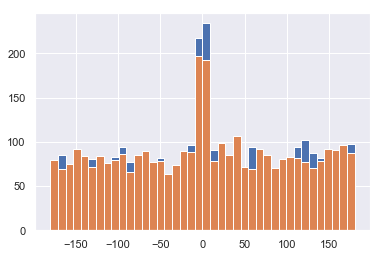

In [51]:
plt.hist(err_bad_chunk, bins = 40)
plt.hist(err_bad, bins = 40)

In [21]:
sir4_chunk_mean, sir4_chunk_std = geterror(base,good)

In [23]:
sir4_chunk_std

1.226385616178796

In [ ]:
#percent correct 

In [ ]:
#just the average absolute errors.

In [ ]:
#model fitting on the top 10 models. 

80
80


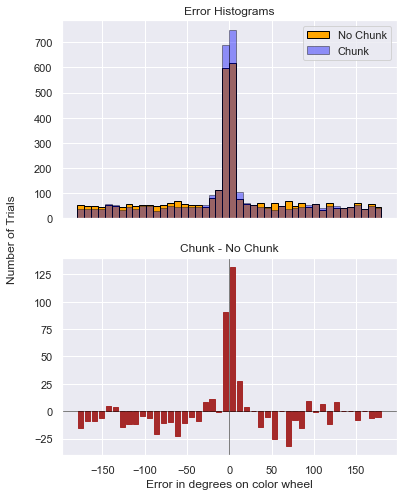

In [25]:
num_models = 80
base= "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
err_good_chunk, good = bestnmodels(base, n = 10)
sir4_chunk_mean, sir4_chunk_std = geterror(base,good)
base2= "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
err_good_nochunk, good = bestnmodels(base2, n = 10)
sir4_nochunk_mean, sir4_nochunk_std = geterror(base2,good)
overlay_hist2_trial(err_good_chunk,err_good_nochunk)

80
80


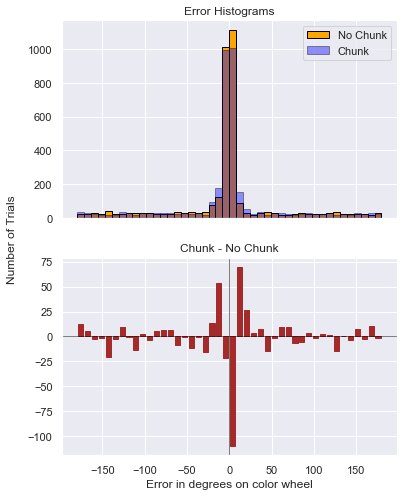

In [27]:
num_models = 80
base= "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/copy/"
err_good_chunk,good = bestnmodels(base)
sir3_chunk_mean, sir3_chunk_std = geterror(base,good)
base2= "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/copy/"
err_good_nochunk, good = bestnmodels(base2)
sir3_nochunk_mean, sir3_nochunk_std = geterror(base2,good)
overlay_hist2_trial(err_good_chunk,err_good_nochunk)

80
80


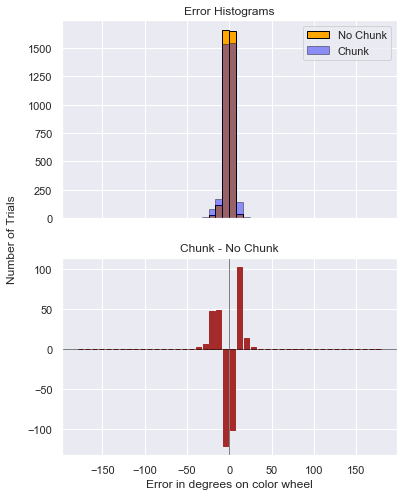

In [28]:
num_models = 80
base= "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
err_good_chunk, good = bestnmodels(base)
sir2_chunk_mean, sir2_chunk_std = geterror(base,good)
base2= "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
err_good_nochunk, good = bestnmodels(base2)
sir2_nochunk_mean, sir2_nochunk_std = geterror(base2,good)
overlay_hist2_trial(err_good_chunk,err_good_nochunk)

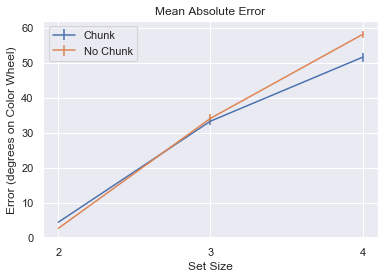

In [40]:
chunk = [sir2_chunk_mean,sir3_chunk_mean,sir4_chunk_mean]
nochunk = [sir2_nochunk_mean,sir3_nochunk_mean,sir4_nochunk_mean]

chunk_std = [sir2_chunk_std,sir3_chunk_std,sir4_chunk_std]
nochunk_std = [sir2_nochunk_std,sir3_nochunk_std,sir4_nochunk_std]
plt.errorbar([2,3,4],chunk,chunk_std)
plt.errorbar([2,3,4],nochunk,nochunk_std)
plt.xticks([2,3,4])
plt.xlabel('Set Size')
plt.ylabel('Error (degrees on Color Wheel)')
plt.title('Mean Absolute Error')
plt.legend(['Chunk', 'No Chunk'])

In [29]:
chunk = [sir2_abe_chunk,sir3_abe_chunk,sir4_abe_chunk]
nochunk = [sir2_abe_nochunk,sir3_abe_nochunk,sir4_abe_nochunk]

chunk_std = [sir2_abe_chunk_std,sir3_abe_chunk_std,sir4_abe_chunk_std]
nochunk_std = [sir2_abe_nochunk_std,sir3_abe_nochunk_std,sir4_abe_nochunk_std]

([<matplotlib.axis.XTick at 0x201bc0374e0>,
 <a list of 3 Text xticklabel objects>)

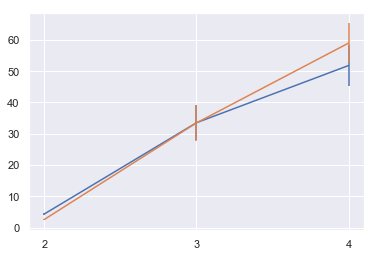

In [30]:
plt.errorbar([2,3,4],chunk,chunk_std)
plt.errorbar([2,3,4],nochunk,nochunk_std)
plt.xticks([2,3,4])

In [ ]:
tasks = [2,3,4]
mse_all_nochunk = [mse_sir2,mse_sir3,mse_sir4]
std_all_nochunk = [std_sir2,std_sir3, std_sir4]

mse_all_chunk = [mse_sir2_chunk,mse_sir3_chunk,mse_sir4_chunk]
std_all_chunk = [std_sir2_chunk,std_sir3_chunk,std_sir4_chunk]

plt.xlim(1.8,4.2)

In [47]:
n = 10
files = os.listdir(base)
full_files = [base+f for f in files if 'Base.csv' in f]
print(len(full_files))    
models = {}
for f in full_files:
    p = Precision()
    err = p.mult_models([f])
    abe = np.mean(np.abs(err))
    models[f] = abe
df1 = pd.Series(models).to_frame()
df = pd.DataFrame(df1)
df_sort = df.sort_values([0])
good = df_sort.index[:n]
p = Precision()
err_good = p.mult_models(good)

80


(array([ 41.,  43.,  43.,  44.,  68.,  49.,  49.,  43.,  47.,  48.,  39.,
         55.,  49.,  59.,  43.,  52.,  48.,  67., 132., 718., 766.,  98.,
         69.,  45.,  42.,  32.,  47.,  44.,  42.,  52.,  62.,  60.,  41.,
         53.,  53.,  45.,  58.,  39.,  46.,  56.]),
 array([-1.7991000e+02, -1.7091925e+02, -1.6192850e+02, -1.5293775e+02,
        -1.4394700e+02, -1.3495625e+02, -1.2596550e+02, -1.1697475e+02,
        -1.0798400e+02, -9.8993250e+01, -9.0002500e+01, -8.1011750e+01,
        -7.2021000e+01, -6.3030250e+01, -5.4039500e+01, -4.5048750e+01,
        -3.6058000e+01, -2.7067250e+01, -1.8076500e+01, -9.0857500e+00,
        -9.5000000e-02,  8.8957500e+00,  1.7886500e+01,  2.6877250e+01,
         3.5868000e+01,  4.4858750e+01,  5.3849500e+01,  6.2840250e+01,
         7.1831000e+01,  8.0821750e+01,  8.9812500e+01,  9.8803250e+01,
         1.0779400e+02,  1.1678475e+02,  1.2577550e+02,  1.3476625e+02,
         1.4375700e+02,  1.5274775e+02,  1.6173850e+02,  1.7072925e+02,
      

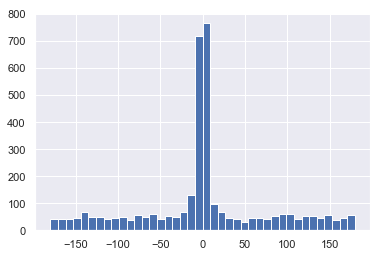

In [51]:
plt.hist(err_good,bins = 40)

In [52]:
base= "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
n = 10
files = os.listdir(base)
full_files = [base+f for f in files if 'Base.csv' in f]
print(len(full_files))    
models = {}
for f in full_files:
    p = Precision()
    err = p.mult_models([f])
    abe = np.mean(np.abs(err))
    models[f] = abe
df1 = pd.Series(models).to_frame()
df = pd.DataFrame(df1)
df_sort = df.sort_values([0])
good = df_sort.index[:n]
p = Precision()
err_good = p.mult_models(good)


80


(array([ 56.,  54.,  52.,  53.,  56.,  50.,  51.,  62.,  51.,  64.,  53.,
         67.,  62.,  78.,  53.,  46.,  70.,  58., 117., 628., 636.,  64.,
         65.,  46.,  59.,  65.,  46.,  61.,  56.,  65.,  59.,  47.,  50.,
         61.,  46.,  52.,  66.,  59.,  51.,  55.]),
 array([-1.79932074e+02, -1.70936011e+02, -1.61939947e+02, -1.52943884e+02,
        -1.43947821e+02, -1.34951758e+02, -1.25955695e+02, -1.16959631e+02,
        -1.07963568e+02, -9.89675050e+01, -8.99714418e+01, -8.09753786e+01,
        -7.19793154e+01, -6.29832522e+01, -5.39871890e+01, -4.49911258e+01,
        -3.59950627e+01, -2.69989995e+01, -1.80029363e+01, -9.00687307e+00,
        -1.08098717e-02,  8.98525332e+00,  1.79813165e+01,  2.69773797e+01,
         3.59734429e+01,  4.49695061e+01,  5.39655693e+01,  6.29616325e+01,
         7.19576957e+01,  8.09537589e+01,  8.99498221e+01,  9.89458853e+01,
         1.07941948e+02,  1.16938012e+02,  1.25934075e+02,  1.34930138e+02,
         1.43926201e+02,  1.52922264e+02, 

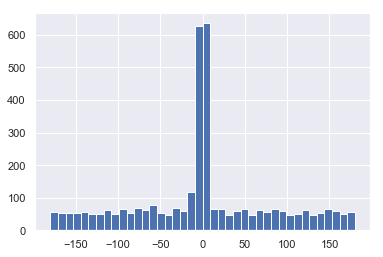

In [53]:
plt.hist(err_good,bins = 40)

In [46]:
df_sort.index[:10]

Index(['Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/sir4chunkhybridmodel2_RewThreshold5.5_decoded_Base.csv',
       'Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/sir4chunkhybridmodel76_RewThreshold5.5_decoded_Base.csv',
       'Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/sir4chunkhybridmodel72_RewThreshold5.5_decoded_Base.csv',
       'Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/sir4chunkhybridmodel58_RewThreshold5.5_decoded_Base.csv',
       'Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/sir4chunk

In [9]:
#getting only the top 10 models based on mse and take only the 10 best models.

def bestnmodels(base,n): #n is the number of models you want to keep; base = fullfile name
    files = os.listdir(base)
    full_files = [base+f for f in files if 'Base.csv' in f]
    print(len(full_files))    
    good = []
    bad =[]
    models = {}
    
    for f in full_files:
        p = Precision()
        err = p.mult_models([f])
        abe = np.mean(np.abs(err))
        model[f] = abe
        
    
        
    return bad, good

In [6]:
#This is step 3

def badmodels(base,cutoff = 1.0): #this should return a list where first part is fullfilename of all the bad models, then all good models. 
    files = os.listdir(base)
    full_files = [base+f for f in files if 'EpcLog' in f]
    
    good = []
    bad =[]
    
    for f in full_files:
        if 'model0_' in f:
            df = pd.read_csv(f, sep = '\t')
            SSE = df['#SSE']
            Epoch = df['|Epoch']
        else:
            df = pd.read_csv(f,sep = '\t', header = None)
            SSE  = df[2]
            Epoch = df[1]
        #import pdb; pdb.set_trace()
        f_hist = f.replace('EpcLog', '')
        if SSE.iloc[-1] <=cutoff:
            good.append(f_hist)
        else:
            bad.append(f_hist)
    
    return bad, good

def plotbadmodels(bad,good,cutof = 1.0):#this should take the fullfilenames of all good,bad models and plot 3 plots - 1 good,1bad, 1 all. 
    allmod = bad+good
   #model_name = allmod[0].split('workingmemory')[1].split('/')[1]
    model_name = allmod[0].split('/')[1]
    if 'decodedrew' in allmod[0]:
        rewardfun = 'Decoded'
    else:
        rewardfun = 'Unit Difference'
        
    plt.figure()
    p = Precision()
    err = p.mult_models(allmod)
    nummodels = len(allmod)
    plt.hist(err, bins = 70)
    plt.title(model_name+", "+rewardfun+" ,"+str(nummodels)+"All Models")
    plt.xlabel('Error (in degrees)')
    plt.ylabel('Frequency')
        
    plt.figure()
    p = Precision()
    nummodels = len(bad)
    if nummodels == 0:
        print('0 Bad Models')
        return
    err = p.mult_models(bad)
    plt.hist(err, bins = 70)
    plt.title(model_name+", "+rewardfun+" ,"+str(nummodels)+"Bad Models")
    plt.xlabel('Error (in degrees)')
    plt.ylabel('Frequency')

    plt.figure()
    p = Precision()
    nummodels = len(good)
    if nummodels == 0:
        print('0 Good Models')
        return
    err = p.mult_models(good)

    plt.hist(err, bins = 70)
    plt.title(model_name+", "+rewardfun+" ,"+str(nummodels)+"Good Models")
    plt.xlabel('Error (in degrees)')
    plt.ylabel('Frequency')




    

In [2]:
def getfiles(base):
    files = os.listdir(base)
    files = [f for f in files if 'Base.csv' in f]
    full_files = [base+f for f in files if 'EpcLog' not in f]
    print("all files: {}".format(len(full_files)))
    return full_files

def getlcfiles(base):
    files = os.listdir(base)
    files = [f for f in files if '.csv' in f]
    full_files = [base+f for f in files if 'EpcLog' in f]
    return full_files
    

def geterror(base, good_models = []):
    full_files = getfiles(base)
    if len(good_models) > 0: 
        new_full_files = []
        for f in range(len(full_files)):
            model_num = full_files[f].split('model')[1].split('_')[0]
            if "model"+model_num+".csv" in good_models:
                       new_full_files.append(full_files[f])
                       
    full_files = new_full_files
    
    num_models = len(full_files)
    print("plotting files: {}".format(num_models))
    p = Precision()
    L1_means = np.zeros(num_models)
    L1_vars = np.zeros(num_models)
    for f in range(len(full_files)):
        err_model = p.mult_models([full_files[f]])
        L1 = np.abs(err_model)
        L1_means[f]=np.mean(L1)
        L1_vars[f] = np.var(L1)
    #mse = np.sqrt(np.mean(err**2)) 
    total_mean = np.mean(L1_means)
    total_var = np.mean(L1_vars)/num_models
    errorbar_std = np.std(L1_means)/np.sqrt(num_models)
    return err_model, total_mean, total_var, errorbar_std
    
def getlc(base):
    full_files = getlcfiles(base)
    num_models = len(full_files)
    SSE=[]
    Epoch = []
    for f in full_files:
        if 'model0_' in f:
            df = pd.read_csv(f, sep = '\t')
            SSE.append(df['#SSE'])
            Epoch.append(df['|Epoch'])
        else:
            df = pd.read_csv(f,sep = '\t', header = None)
            SSE.append(df[2])
    SSE_np = np.array(SSE)
    SSE_avg = np.mean(SSE_np, axis = 0)
    SSE_std = np.std(SSE_np, axis = 0)/np.sqrt(num_models)
    #plt.plot(Epoch[0],SSE_avg)
    
    return Epoch[0], SSE_avg, SSE_std 
    

def geterror_array(base, good_models = [], bad = False):
    full_files = getfiles(base)
    if bad:
        if len(good_models) > 0:
            good_files = []
            bad_files = []
            for f in range(len(full_files)):
                model_num = full_files[f].split('model')[1].split('_')[0]
                if "model"+model_num+".csv" in good_models or "model"+model_num+"err.csv" in good_models:
                    good_files.append(full_files[f])
                else:
                    bad_files.append(full_files[f])
        num_models = len(good_files)
        print("Good files: {}".format(num_models))
        p = Precision()
        errgood = p.mult_models(good_files)
        p = Precision()
        errbad = p.mult_models(bad_files)
        return errgood, errbad
                
    else:
        if len(good_models) > 0: 
            new_full_files = []
            for f in range(len(full_files)):
                model_num = full_files[f].split('model')[1].split('_')[0]
                if "model"+model_num+".csv" in good_models or "model"+model_num+"err.csv" in good_models:
                           new_full_files.append(full_files[f])
        full_files = new_full_files
        num_models = len(full_files)
        print("plotting files: {}".format(num_models))
        p = Precision()
        err = p.mult_models(full_files)
        return err

def plot_title(base):
    
    if 'contexp' in base:
        rewardtype = 'Continuous Exponential'
    elif 'RewThresh' in base:
        rewardtype = 'Binary'
    else:
        rewardtype = 'Continuous Linear'
        
    if 'decodedrew' in base:
        rewardfun = 'Decoded'
    else: 
        rewardfun = 'Unit Difference'
        
    if 'NoStimLoc' in base:
        stimloc = ', No Stim Loc'
    else: 
        stimloc = ", Stim Loc Used"
   
    if 'NoIgnore' in base:
        ignore = ', No Ignore Trials'
    else:
        ignore = ''

    if "StimRange0to45" in base:
        stim_dist = ', StimDist Max 45'
    else:
        stim_dist = ""


    title = 'Reward Function: ' + rewardtype +', ' +rewardfun +stimloc + ignore +stim_dist#+' '+additional_title
    return title


def mse_allmodels(base, base2, experiment, plot_errorbars = True, good_models = []):
    sir2_file = base + "sir2_new/" +base2+experiment
    sir2_chunk_file = base + "sir2_chunk/" +base2+"hybrid/"+experiment
    sir3_file = base + "sir3/" +base2+experiment
    sir3_chunk_file = base + "sir3_chunk/" +base2+"hybrid/"+experiment
    sir4_file = base + "sir4/" +base2+experiment
    sir4_chunk_file = base + "sir4_chunk/" +base2+"hybrid/"+experiment
    
    if len(good_models) > 0:
        print('sir2')
        err_sir2, mse_sir2, var_sir2, std_sir2 = geterror(sir2_file, good_models['sir2'])
        print('sir2_chunk')
        err_sir2_chunk, mse_sir2_chunk, var_sir2_chunk,std_sir2_chunk = geterror(sir2_chunk_file, good_models['sir2_chunk'])
        print('sir3')
        err_sir3, mse_sir3, var_sir3,std_sir3 = geterror(sir3_file, good_models['sir3'])
        print('sir3_chunk')
        err_sir3_chunk, mse_sir3_chunk, var_sir3_chunk,std_sir3_chunk = geterror(sir3_chunk_file, good_models['sir3_chunk'])
        print('sir4')
        err_sir4, mse_sir4, var_sir4,std_sir4 = geterror(sir4_file, good_models['sir4'])
        print('sir4_chunk')
        err_sir4_chunk, mse_sir4_chunk, var_sir4_chunk,std_sir4_chunk = geterror(sir4_chunk_file, good_models['sir4_chunk'])
    else: 
        err_sir2, mse_sir2, var_sir2, std_sir2 = geterror(sir2_file)
        err_sir2_chunk, mse_sir2_chunk, var_sir2_chunk,std_sir2_chunk = geterror(sir2_chunk_file)
        err_sir3, mse_sir3, var_sir3,std_sir3 = geterror(sir3_file, good_models['sir3'])
        err_sir3_chunk, mse_sir3_chunk, var_sir3_chunk,std_sir3_chunk = geterror(sir3_chunk_file)
        err_sir4, mse_sir4, var_sir4,std_sir4 = geterror(sir4_file, good_models['sir4'])
        err_sir4_chunk, mse_sir4_chunk, var_sir4_chunk,std_sir4_chunk = geterror(sir4_chunk_file)
    

    title = plot_title(sir2_file)
    tasks = [2,3,4]
    mse_all_nochunk = [mse_sir2,mse_sir3,mse_sir4]
    std_all_nochunk = [std_sir2,std_sir3, std_sir4]

    mse_all_chunk = [mse_sir2_chunk,mse_sir3_chunk,mse_sir4_chunk]
    std_all_chunk = [std_sir2_chunk,std_sir3_chunk,std_sir4_chunk]

    plt.xlim(1.8,4.2)
    
    if plot_errorbars == True:
        plt.errorbar(tasks,mse_all_nochunk,std_all_nochunk)
        plt.errorbar(tasks,mse_all_chunk, std_all_chunk)
    else:
        plt.plot(tasks,mse_all_nochunk)
        plt.plot(tasks,mse_all_chunk)

        
    plt.xticks(tasks)
    plt.ylabel('Absolute Error Averaged over Models')
    #plt.ylabel(r'$\sqrt{MSE}$')
    plt.xlabel('Number of Items')
    plt.legend(['No Chunk', 'Chunk'], loc = 'lower right')
    plt.title(title)
    
def lc_allmodels(base,base2,experiment, plot_errorbars = True, sir4 = False):
    sir2_file = base + "sir2_new/" +base2+experiment
    sir2_chunk_file = base + "sir2_chunk/" +base2+"hybrid/"+experiment
    sir3_file = base + "sir3/" +base2+experiment
    sir3_chunk_file = base + "sir3_chunk/" +base2+"hybrid/"+experiment
    if sir4:
        sir4_file = base + "sir4/" +base2+experiment
        sir4_chunk_file = base + "sir4_chunk/" +base2+"hybrid/"+experiment
    
    _, SSE_sir2, std_sir2 = getlc(sir2_file)
    _, SSE_sir2_chunk, std_sir2_chunk = getlc(sir2_chunk_file)
    _, SSE_sir3, std_sir3 = getlc(sir3_file)
    Epoch, SSE_sir3_chunk, std_sir3_chunk = getlc(sir3_chunk_file)
    if sir4:
        _, SSE_sir4, std_sir4 = getlc(sir4_file)
        _, SSE_sir4_chunk, std_sir4_chunk = getlc(sir4_chunk_file)
    
    title = plot_title(sir2_file)
    plt.figure()
    if plot_errorbars:
        plt.errorbar(Epoch,SSE_sir2,std_sir2)
        plt.errorbar(Epoch,SSE_sir2_chunk, std_sir2_chunk)

    else:
        plt.plot(Epoch,SSE_sir2)
        plt.plot(Epoch,SSE_sir2_chunk)
    
    plt.title(title+ ', SIR 2 Task')
    plt.xlabel('Epoch')
    plt.ylabel('SSE')
    plt.legend(['No Chunk', 'Chunk'])
    
    plt.figure()
    if plot_errorbars:
        plt.errorbar(Epoch,SSE_sir3, std_sir3)
        plt.errorbar(Epoch,SSE_sir3_chunk, std_sir3_chunk)
    else:
        plt.plot(Epoch,SSE_sir3)
        plt.plot(Epoch,SSE_sir3_chunk)
        
    plt.title(title+ ', SIR 3 Task')
    plt.xlabel('Epoch')
    plt.ylabel('SSE')
    plt.legend(['No Chunk', 'Chunk'])
    
    if sir4:
        plt.figure()
        if plot_errorbars:
            plt.errorbar(Epoch,SSE_sir4, std_sir4)
            plt.errorbar(Epoch,SSE_sir4_chunk, std_sir4_chunk)
        else:
            plt.plot(Epoch,SSE_sir4)
            plt.plot(Epoch,SSE_sir4_chunk)

        plt.title(title+ ', SIR 4 Task')
        plt.xlabel('Epoch')
        plt.ylabel('SSE')
        plt.legend(['No Chunk', 'Chunk'])


def plot_allhist(base,base2,experiment, good_models = [], overlay = False):
    sir2_file = base + "sir2_new/" +base2+experiment
    sir2_chunk_file = base + "sir2_chunk/" +base2+"hybrid/"+experiment
    sir3_file = base + "sir3/" +base2+experiment
    sir3_chunk_file = base + "sir3_chunk/" +base2+"hybrid/"+experiment
    sir4_file = base + "sir4/" +base2+experiment
    sir4_chunk_file = base + "sir4_chunk/" +base2+"hybrid/"+experiment
        
    if overlay: 
        title = plot_title(sir2_file)
        
        plt.figure()
        err = geterror_array(sir2_file,good_models['sir2'])       
        plt.hist(err, bins = 50, alpha = 0.6, density = True)        
        err = geterror_array(sir2_chunk_file,good_models['sir2_chunk'])
        plt.hist(err, bins = 50, color = "yellow", alpha = 0.6, density = True)   
        plt.legend(['No Chunk', 'Chunk'])
        plt.title("Task 2, "+title)
        
        plt.figure()
        err = geterror_array(sir3_file,good_models['sir3'])
        plt.hist(err, bins = 50, alpha = 0.6, density = True)
        err = geterror_array(sir3_chunk_file,good_models['sir3_chunk'])
        plt.hist(err, bins = 50, color = 'yellow', alpha = 0.6, density = True)
        plt.legend(['No Chunk', 'Chunk'])
        plt.title("Task 3, "+title)
        
        plt.figure()
        err = geterror_array(sir4_file,good_models['sir4'])
        plt.hist(err, bins = 50, alpha = 0.6, density = True)
        err = geterror_array(sir4_chunk_file,good_models['sir4_chunk'])
        plt.hist(err, bins = 50, color = 'yellow', alpha = 0.6, density = True)
        plt.legend(['No Chunk', 'Chunk'])
        plt.title("Task 4, "+title)
        
        
    else: 
        title = plot_title(sir2_file)
        errgood, errbad = geterror_array(sir2_file,good_models['sir2'], bad = True)
        plt.figure()
        plt.hist(errgood, bins = 50,alpha = 0.6, density = True)
        plt.hist(errbad,bins = 50,color = 'yellow', alpha = 0.6, density = True )
        plt.legend(['Good Models', 'Bad Models'])
        plt.title("Task 2, No Chunk, "+title)

        errgood, errbad = geterror_array(sir2_chunk_file,good_models['sir2_chunk'], bad = True)
        plt.figure()
        plt.hist(errgood, bins = 50,alpha = 0.6, density = True)
        plt.hist(errbad,bins = 50,color = 'yellow', alpha = 0.6, density = True )
        plt.legend(['Good Models', 'Bad Models'])
        plt.title("Task 2, Chunk, "+title)

        errgood, errbad = geterror_array(sir3_file,good_models['sir3'], bad = True)
        plt.figure()
        plt.hist(errgood, bins = 50,alpha = 0.6, density = True)
        plt.hist(errbad,bins = 50,color = 'yellow', alpha = 0.6, density = True )
        plt.legend(['Good Models', 'Bad Models'])
        plt.title("Task 3, No Chunk, "+title)

        errgood, errbad = geterror_array(sir3_chunk_file,good_models['sir3_chunk'], bad = True)
        plt.figure()
        plt.hist(errgood, bins = 50,alpha = 0.6, density = True)
        plt.hist(errbad,bins = 50,color = 'yellow', alpha = 0.6, density = True )
        plt.legend(['Good Models', 'Bad Models'])
        plt.title("Task 3, Chunk, "+title)

        errgood, errbad = geterror_array(sir4_file,good_models['sir4'], bad = True)
        plt.figure()
        plt.hist(errgood, bins = 50,alpha = 0.6, density = True)
        plt.hist(errbad,bins = 50,color = 'yellow', alpha = 0.6, density = True )
        plt.legend(['Good Models', 'Bad Models'])
        plt.title("Task 4, No Chunk, "+title)

        errgood, errbad = geterror_array(sir4_chunk_file,good_models['sir4_chunk'], bad = True)
        plt.figure()
        plt.hist(errgood, bins = 50,alpha = 0.6, density = True)
        plt.hist(errbad,bins = 50,color = 'yellow', alpha = 0.6, density = True )
        plt.legend(['Good Models', 'Bad Models'])
        plt.title("Task 4, Chunk, "+title)
    
    


In [86]:
def findgoodmodels(base, experiment, gcutoff = 0.7, tasks = 'all'):
    #base is base file location; experiment is specific folder; gcut off is the cut off value for guessing that should be in the model. 
    #for tasks - sir2_new, sir2_chunk etc. to specify tasks. 
    if tasks == 'all':
        df = pd.read_csv(base+experiment+"sir2.csv")
        df_good = df[df['g'] <=gcutoff]
        model_names = df_good['Name'].values
        good_models = {"sir2": model_names}

        df = pd.read_csv(base+experiment+"sir2_chunk.csv")
        df_good = df[df['g'] <=gcutoff]
        model_names = df_good['Name'].values
        good_models["sir2_chunk"] = model_names

        df = pd.read_csv(base+experiment+"sir3.csv")
        df_good = df[df['g'] <=gcutoff]
        model_names = df_good['Name'].values
        good_models["sir3"] =  model_names

        df = pd.read_csv(base+experiment+"sir3_chunk.csv")
        df_good = df[df['g'] <=gcutoff]
        model_names = df_good['Name'].values
        good_models["sir3_chunk"] =  model_names

        df = pd.read_csv(base+experiment+"sir4.csv")
        df_good = df[df['g'] <=gcutoff]
        model_names = df_good['Name'].values
        good_models["sir4"] = model_names

        df = pd.read_csv(base+experiment+"sir4_chunk.csv")
        df_good = df[df['g'] <=gcutoff]
        model_names = df_good['Name'].values
        good_models["sir4_chunk"] = model_names
    else: 
        good_models ={}
        for t in tasks:
            df = pd.read_csv(base+experiment+t)
            df_good = df[df['g'] <=gcutoff]
            model_names = df_good['Name'].values
            good_models[t] = model_names
        
    
    return good_models

def find_model_mse(base, sep = '\s+'):
    full_files = getfiles(base)
    model = []
    ABEs = []
    for f in range(len(full_files)):
        model_num = full_files[f].split('model')[1].split('_')[0]
        p = Precision()
        df = pd.read_csv(full_files[f], sep = sep)
        _,err = p.get_diffs(df, nonresponse = 'guess')
        ABE = np.mean(np.abs(err))
        ABEs.append(ABE)
        model.append(model_num)
    model_ABE = {}
    model_ABE['Model'] = model
    model_ABE['ABE'] = ABEs
    return model_ABE

def goodmodels_mse(model_ABE, cutoff = 50, mse_cutoff = 70, cutoff_type = 'mse_cutoff'):
    df_ABE = pd.DataFrame(model_ABE)
    df_ABE = df_ABE.sort_values(by = ['ABE'])
    if cutoff_type == 'model':
        good_models= df_ABE['Model'][:cutoff].values
    elif cutoff_type == 'mse_cutoff':
        df_good = df_ABE[df_ABE['ABE']<mse_cutoff]
        good_models = df_good['Model'].values
    return good_models 
    

def plot_badmodels(base, good_models = [], bad_models= [], ind = False):
#     errgood,errbad = geterror_array(base, good_models, bad = True)
#     plt.hist(errbad)
#     plt.title('bad models combined')
#     plt.figure()
#     plt.hist(errgood)
#     plt.title('good models combined')
    
    full_files = getfiles(base)
    good_files = []
    bad_files = []
    for f in range(len(full_files)):
        model_num = full_files[f].split('model')[1].split('_')[0]
#         if len(good_models)>0:
#             if "model"+model_num+".csv" in good_models or "model"+model_num+"err.csv" in good_models:
#                 good_files.append(full_files[f])
#             else:
#                 bad_files.append(full_files[f])
#         else:
#             if "model"+model_num+".csv" in bad_models or "model"+model_num+"err.csv" in bad_models:
#                 bad_files.append(full_files[f])
#             else:
#                 good_files.append(full_files[f])
        if len(good_models)>0:
            if model_num in good_models:
                good_files.append(full_files[f])
            else:
                bad_files.append(full_files[f])
        else:
            if model_num in bad_models:
                bad_files.append(full_files[f])
            else:
                good_files.append(full_files[f])
    if ind:
        for f in bad_files: 
            plt.figure()
            p = Precision()
            err = p.mult_models([f])
            plt.hist(err)
            model_num = f.split('model')[1].split('_')[0]
            plt.title('Bad model, '+model_num)
        for f in good_files:
            plt.figure()
            p = Precision()
            err = p.mult_models([f])
            plt.hist(err)
            model_num = f.split('model')[1].split('_')[0]
            plt.title('Good model, '+model_num)
    plt.figure()
    p = Precision()
    err = p.mult_models(bad_files)
    plt.hist(err, 40)
    plt.title("Bad Models")
    
    plt.figure()
    p = Precision()
    err = p.mult_models(good_files)
    plt.hist(err, 40)
    plt.title("Good Models")


all files: 80
all files: 80
17


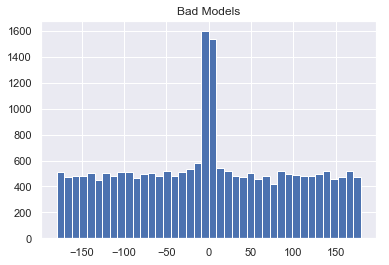

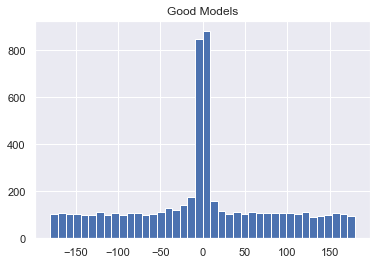

In [92]:
base = 'Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Testfillstim/'
model_ABE = find_model_mse(base)
good_models = goodmodels_mse(model_ABE)
plot_badmodels(base = base, good_models =list(good_models))
print(len(good_models))

In [95]:
good_models

array(['35', '52', '54', '27', '61', '76', '37', '49', '73', '24', '36',
       '67', '10', '15', '69', '70', '7', '74', '48', '59', '50', '32',
       '33', '2', '62', '47', '53', '4', '75', '71', '0', '22'],
      dtype=object)

all files: 80
all files: 80
32


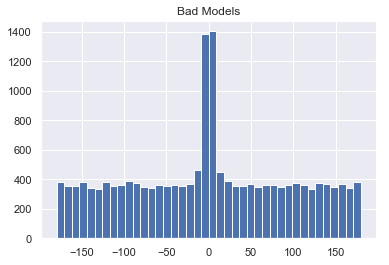

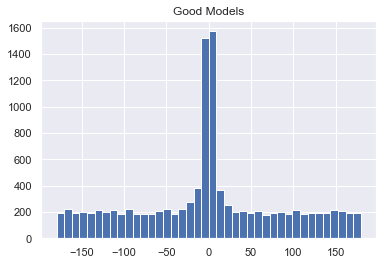

In [94]:
base = 'Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Testfillstim/'
model_ABE = find_model_mse(base)
good_models = goodmodels_mse(model_ABE)
plot_badmodels(base = base, good_models =list(good_models))
print(len(good_models))

all files: 80
all files: 80
13


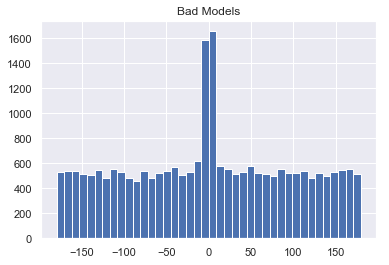

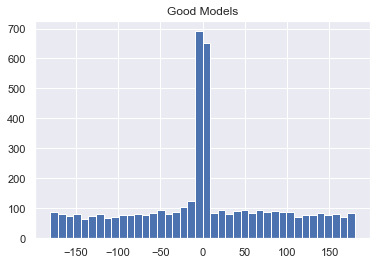

In [90]:
base = 'Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/fillstim/'
model_ABE = find_model_mse(base)
good_models = goodmodels_mse(model_ABE)
plot_badmodels(base = base, good_models =list(good_models))
print(len(good_models))

all files: 80
all files: 80
34


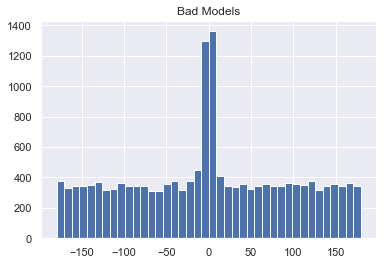

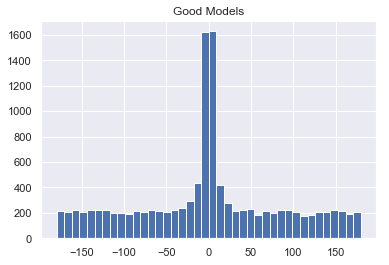

In [91]:
base = 'Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/fillstim/'
model_ABE = find_model_mse(base)
good_models = goodmodels_mse(model_ABE)
plot_badmodels(base = base, good_models =list(good_models))
print(len(good_models))

all files: 80
all files: 80


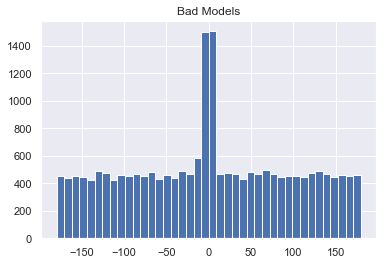

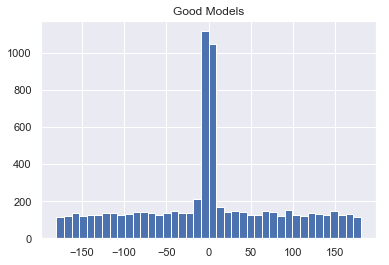

In [88]:
base = 'Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/traintrials/'
model_ABE = find_model_mse(base)
good_models = goodmodels_mse(model_ABE)
plot_badmodels(base = base, good_models =list(good_models))

In [89]:
len(good_models)

21

In [80]:
base = 'Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/traintrials/'
model_ABE = find_model_mse(base)

all files: 80


all files: 80


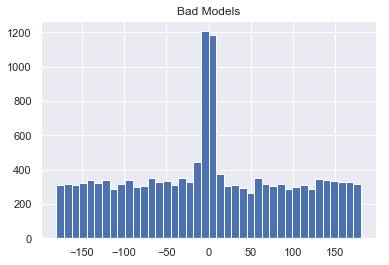

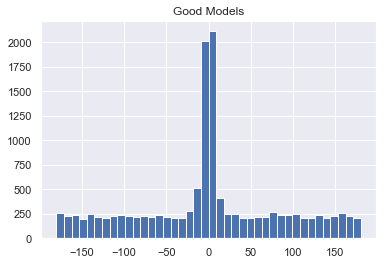

In [87]:
good_models = goodmodels_mse(model_ABE)
plot_badmodels(base = base, good_models =list(good_models))

In [68]:
good_models

array(['34', '44', '68', '59', '54', '14', '56', '72', '21', '25', '79',
       '58', '47', '30', '75', '4', '39', '15', '48', '2', '37', '69',
       '66', '3', '71', '43', '18', '17', '55', '23', '38', '61', '35',
       '27', '10', '63', '28', '67', '9', '42', '31', '60', '62', '41',
       '13', '20', '6', '5', '49', '45', '22', '0', '57', '73', '40',
       '29', '52', '8', '70', '53', '78', '33', '65', '74', '77', '76',
       '11', '51', '16', '12', '24', '36', '1', '32', '50', '46', '26',
       '7', '19', '64'], dtype=object)

all files: 80


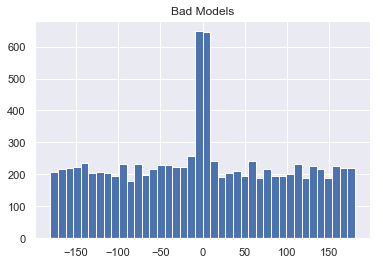

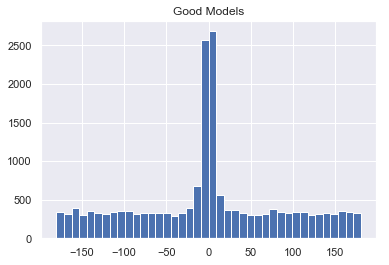

In [13]:
base = 'Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/traintrials/'
bad_models = ['1', '5', '7', '8','11','12', '16', '19', '20', '22', '24', '26', '31', '32', '33', '36', '45', '46', '50', '51', '64', '70', '73', '74', '76', '77', '78']
plot_badmodels(base = base,bad_models = bad_models)

(array([37., 24., 29., 22., 66., 81., 16., 35., 13., 27.]),
 array([-1.7980e+02, -1.4383e+02, -1.0786e+02, -7.1890e+01, -3.5920e+01,
         5.0000e-02,  3.6020e+01,  7.1990e+01,  1.0796e+02,  1.4393e+02,
         1.7990e+02]),
 <a list of 10 Patch objects>)

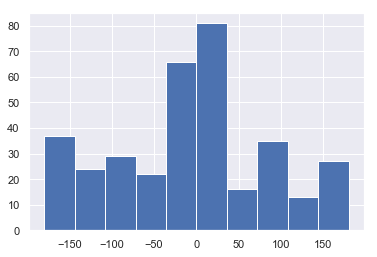

In [54]:
p = Precision()
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
plot_badmodels(base,good_models)

In [80]:
base = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/fits/'
experiment = 'nonresponseswap/'
gcutoff  = 0.4
df = pd.read_csv(base+experiment+"sir4_chunk.csv")
df_good = df[df['g'] <=gcutoff]
model_names = df_good['Name'].values
good_models["sir4_chunk"] = model_names

In [81]:
df

,g,sd,swap,Name
0,0.774173,7.826338e-03,5.969378e+00,model0err.csv
1,0.056740,9.677528e-02,1.116276e+02,model10err.csv
2,0.923189,7.640531e-05,2.414363e+00,model11err.csv
3,0.846305,2.845875e-03,4.370413e+00,model12err.csv
4,0.700502,1.595581e-05,2.563091e+00,model13err.csv
5,0.860393,1.607635e-03,4.427678e+00,model14err.csv
6,0.746010,1.526029e-03,4.456782e+00,model15err.csv
7,0.916557,6.096898e-04,3.812725e+00,model16err.csv
8,0.717976,4.029942e-04,8.089488e+00,model17err.csv
9,0.219437,2.520327e-01,5.375110e+32,model18err.csv


all files: 80
Good files: 69
all files: 80


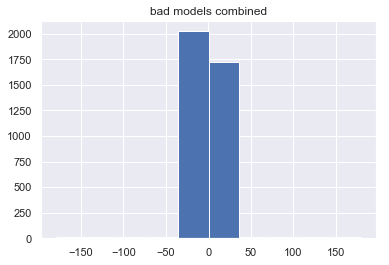

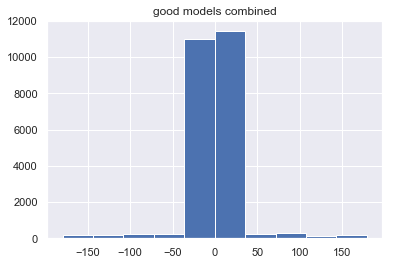

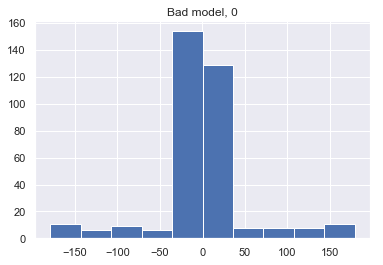

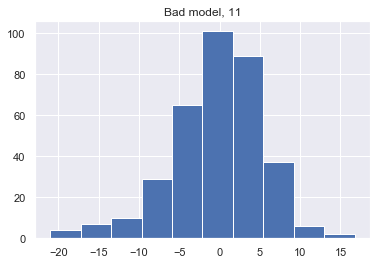

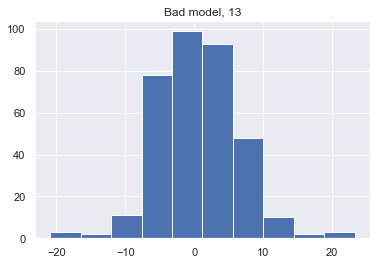

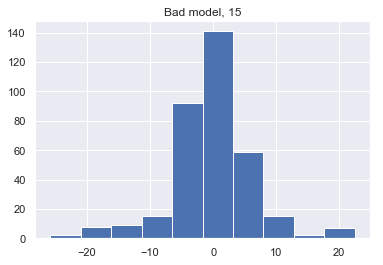

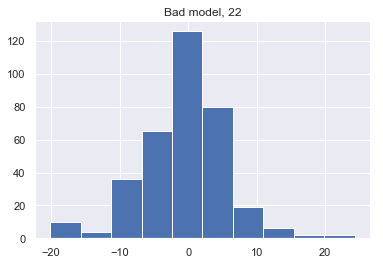

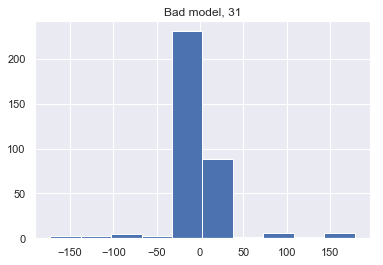

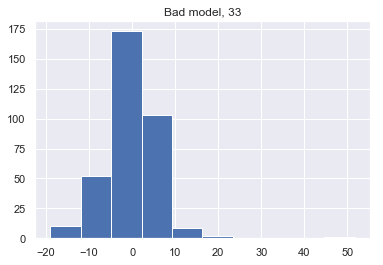

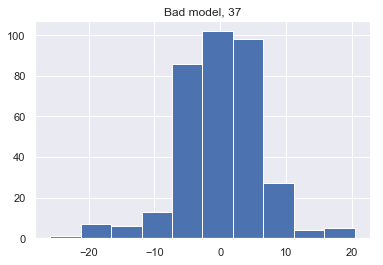

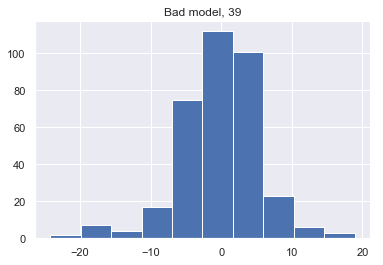

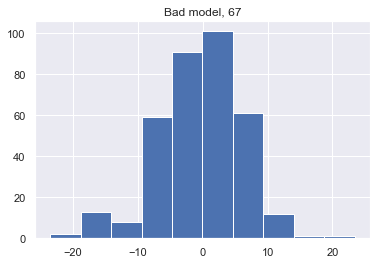

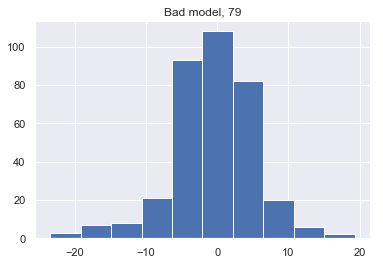

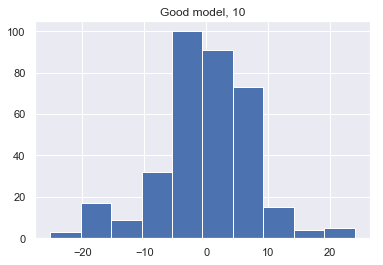

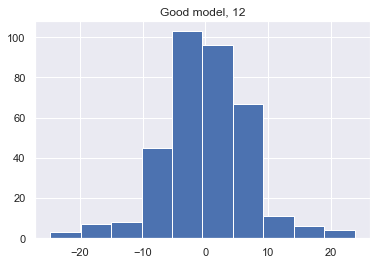

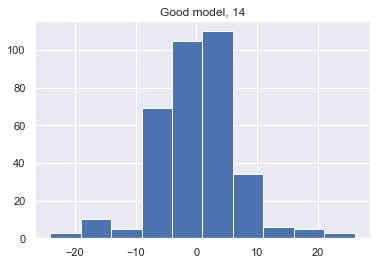

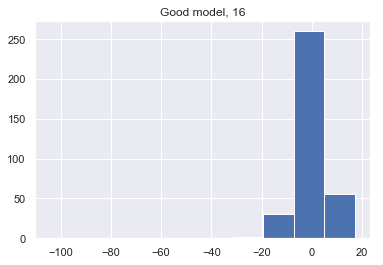

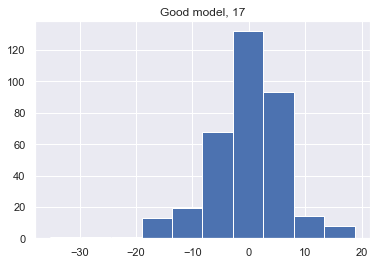

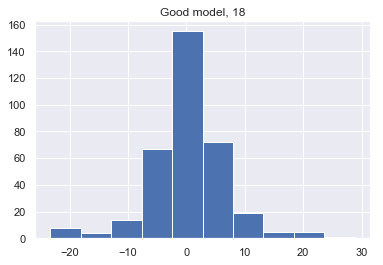

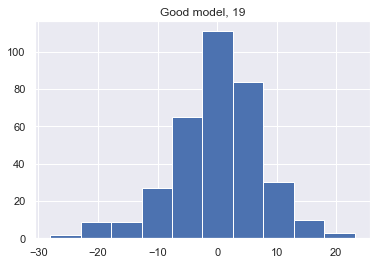

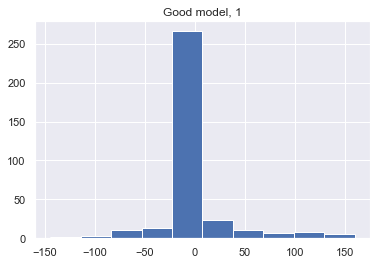

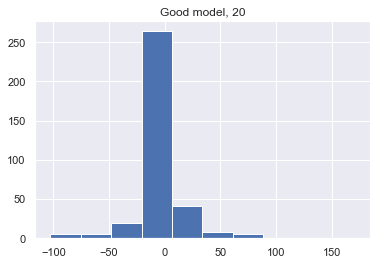

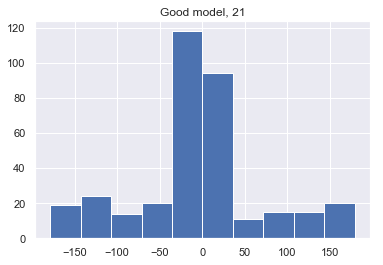

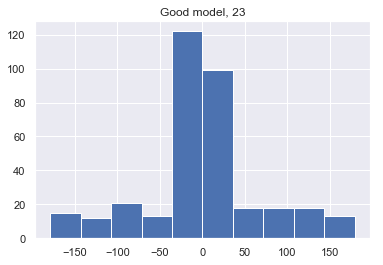

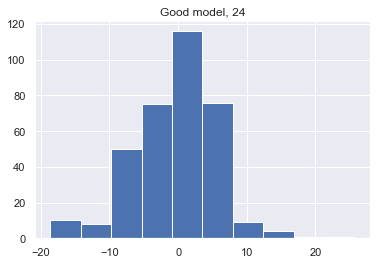

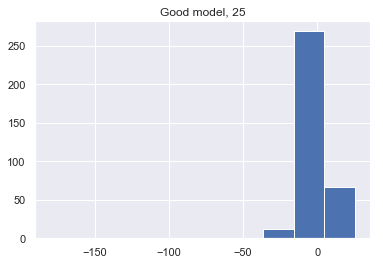

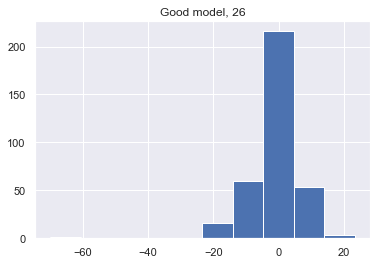

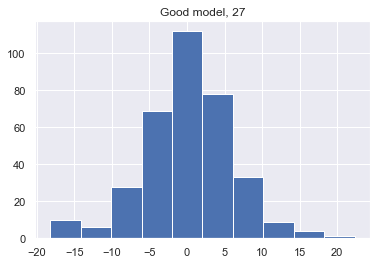

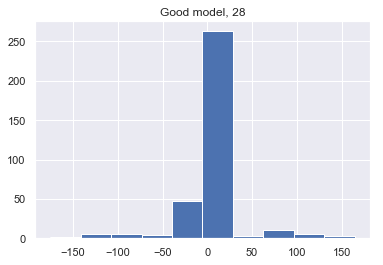

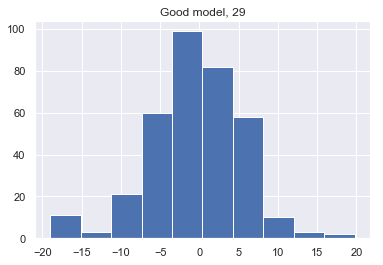

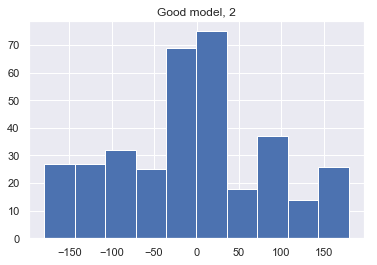

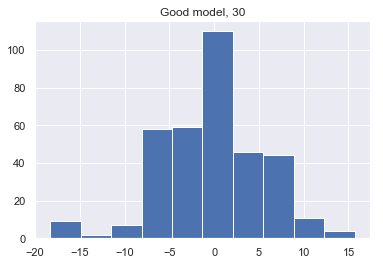

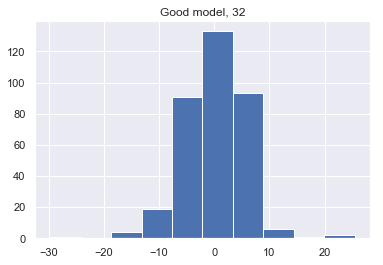

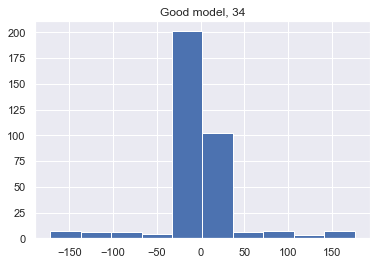

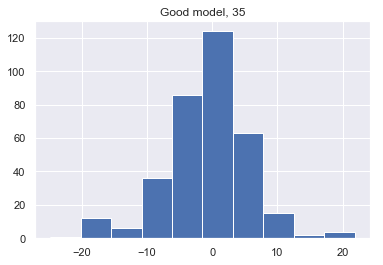

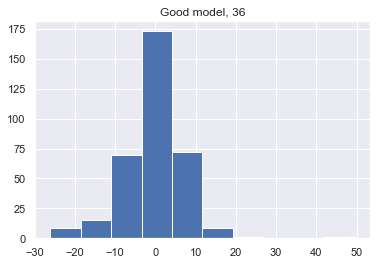

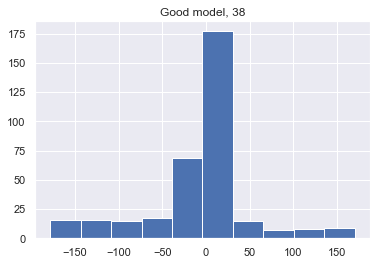

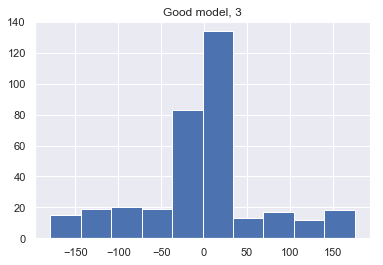

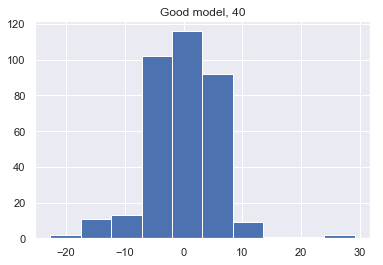

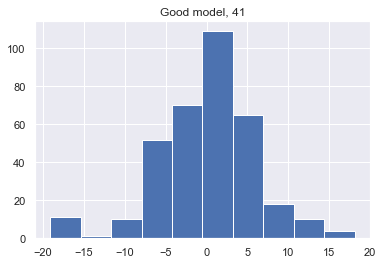

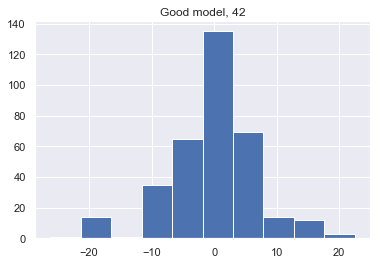

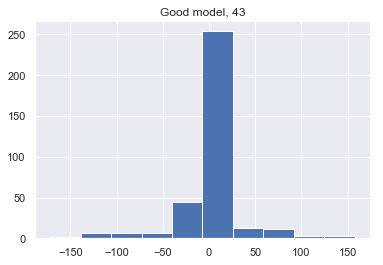

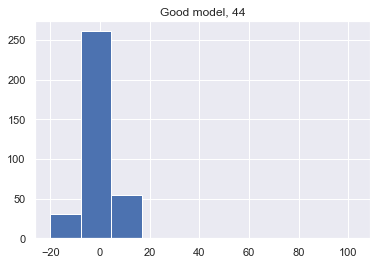

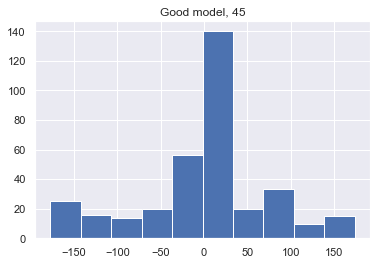

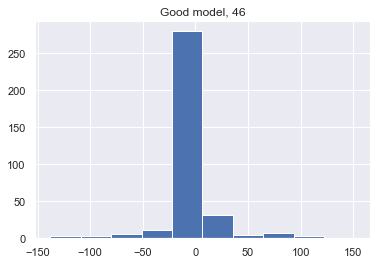

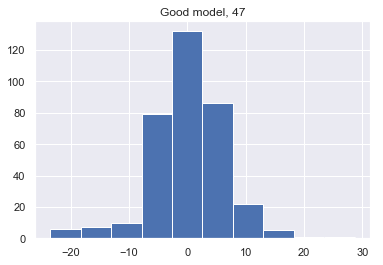

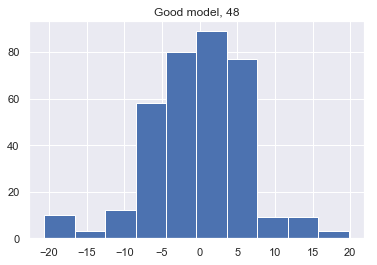

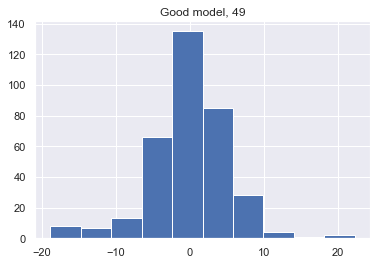

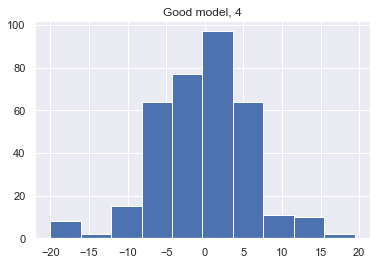

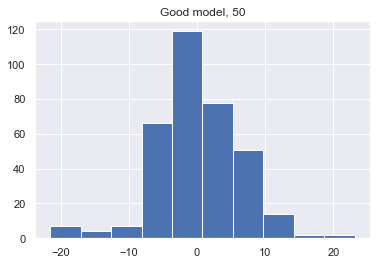

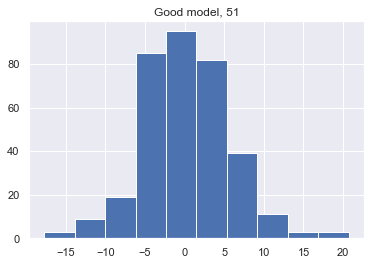

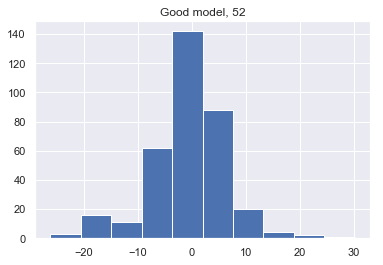

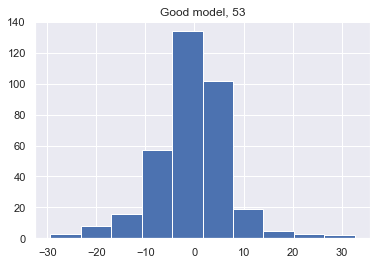

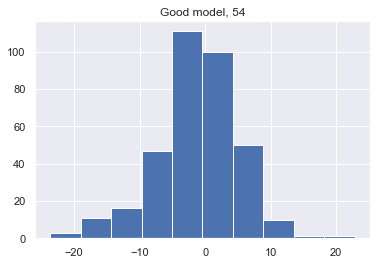

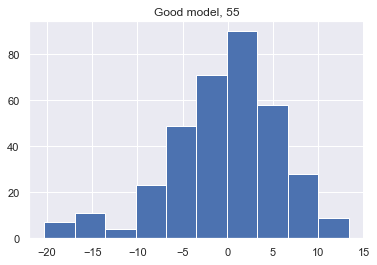

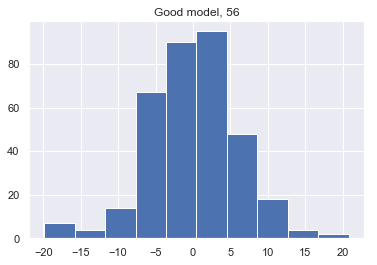

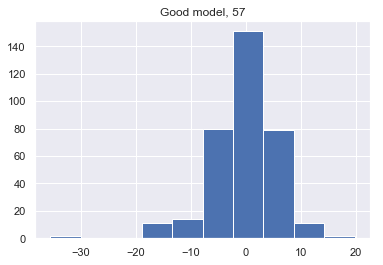

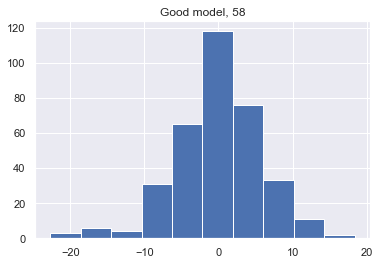

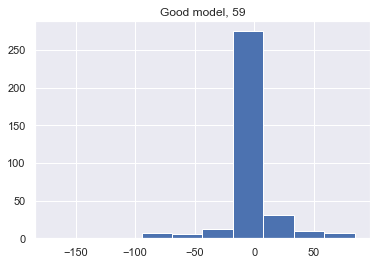

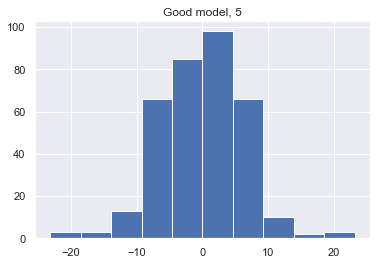

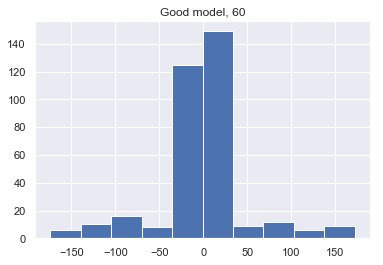

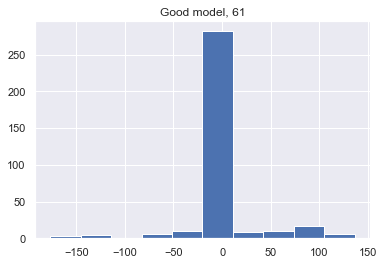

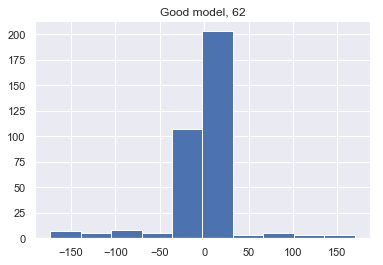

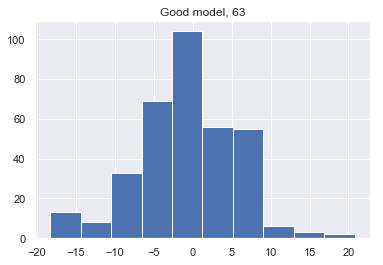

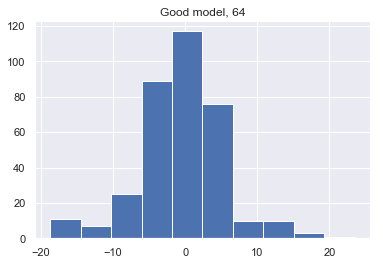

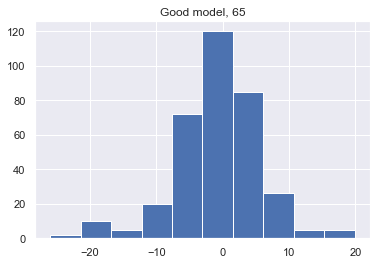

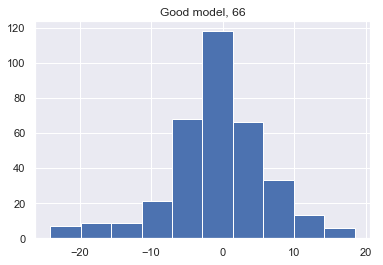

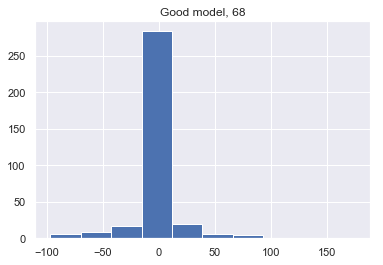

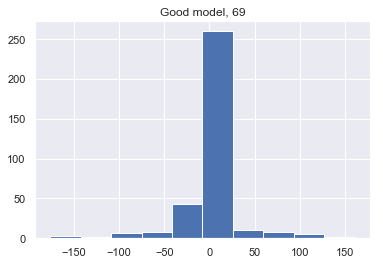

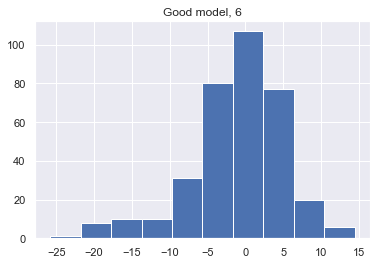

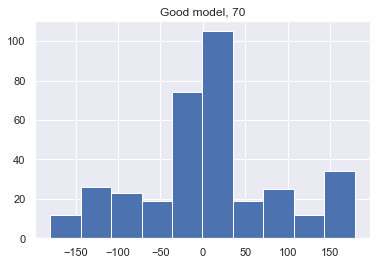

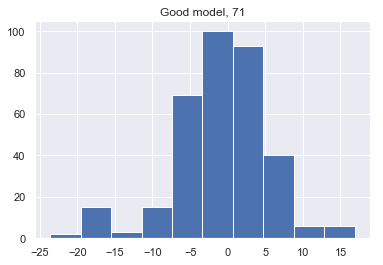

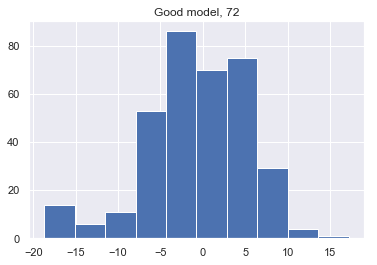

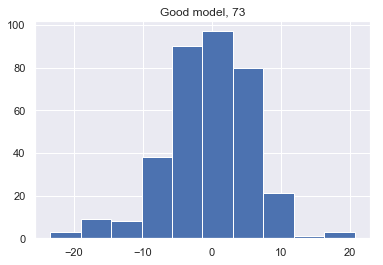

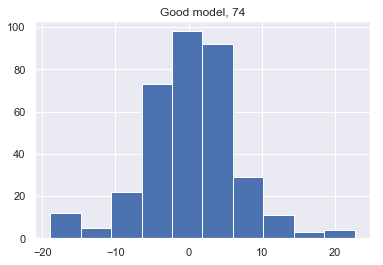

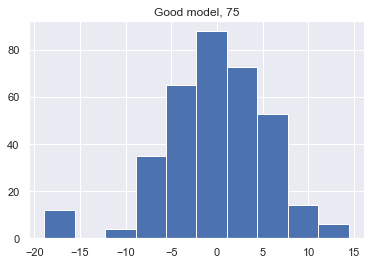

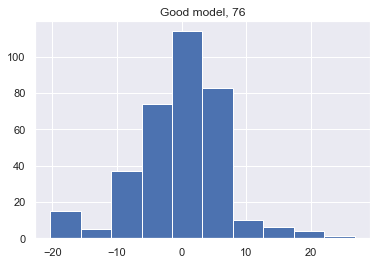

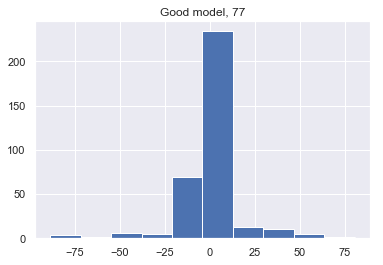

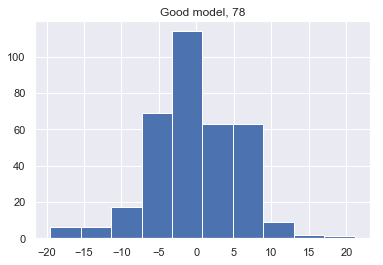

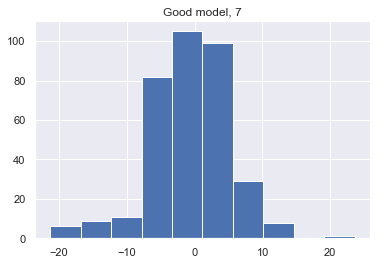

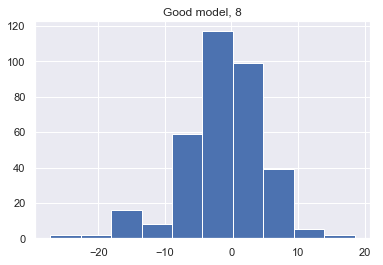

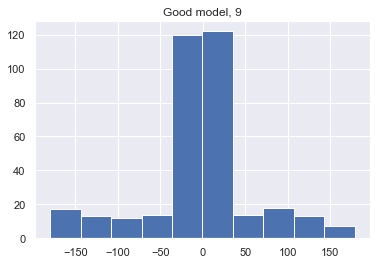

In [67]:
base = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/fits/'
experiment = 'nonresponseswap/'
good_models = findgoodmodels(base,experiment, gcutoff = 0.4,tasks = ['sir2_chunk.csv'])
plot_badmodels("Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/", good_models['sir2_chunk.csv'])

all files: 80
Good files: 2
all files: 80


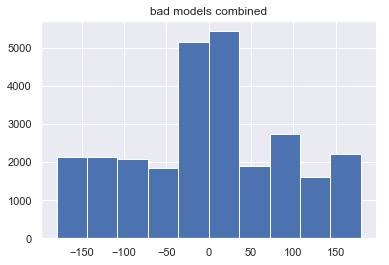

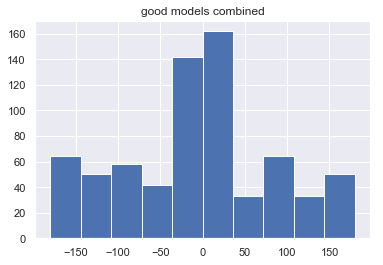

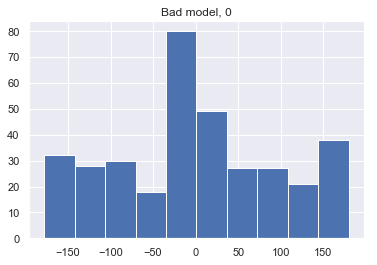

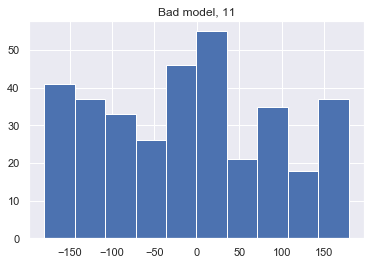

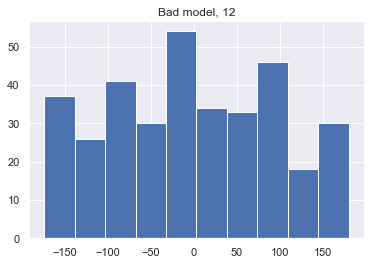

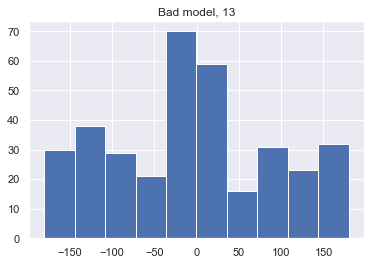

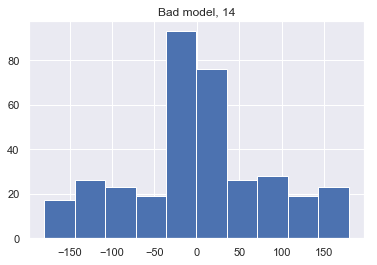

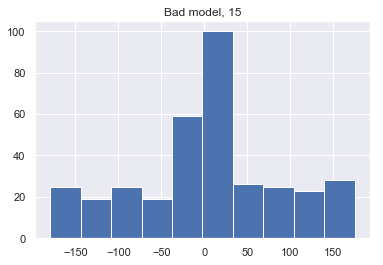

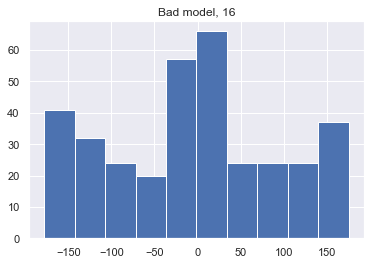

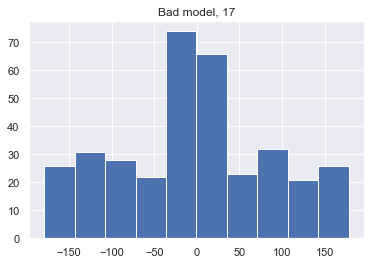

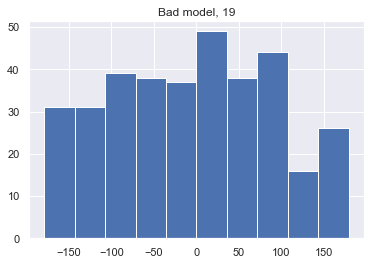

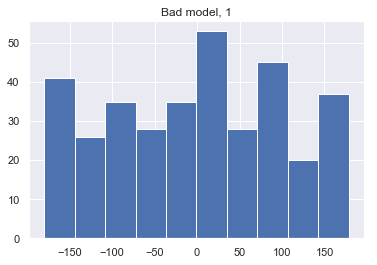

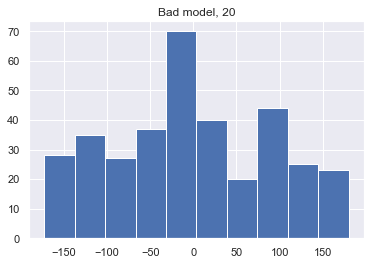

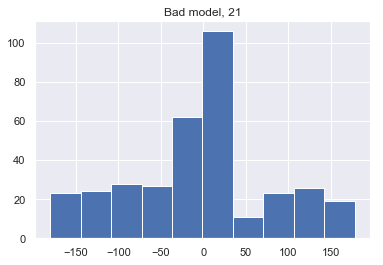

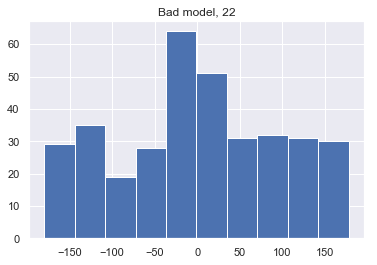

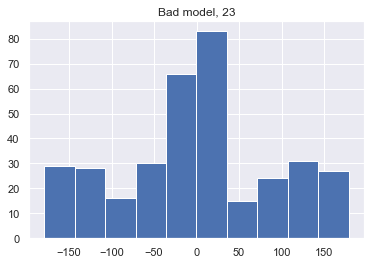

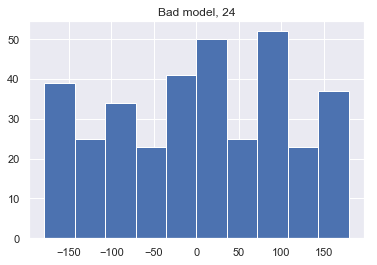

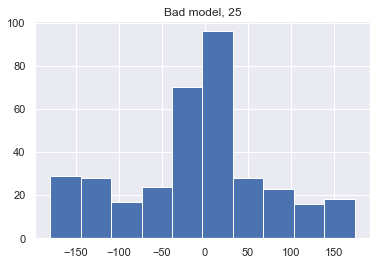

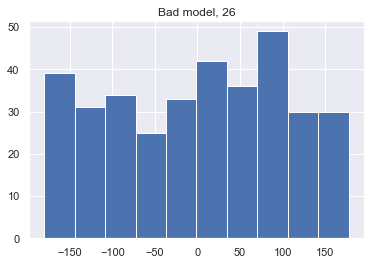

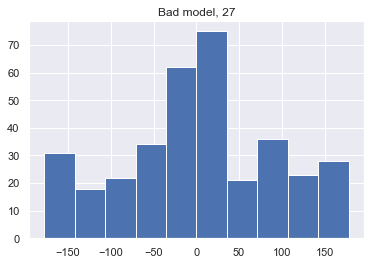

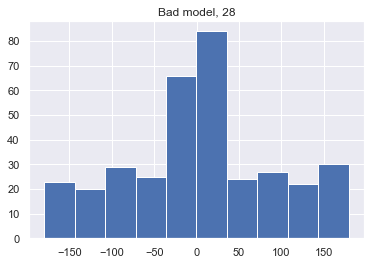

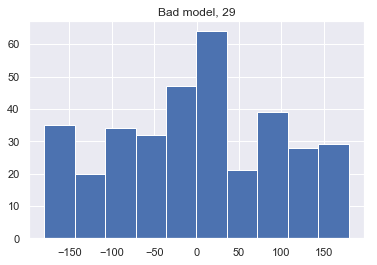

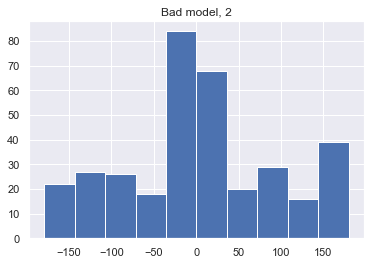

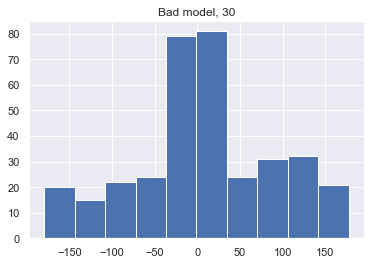

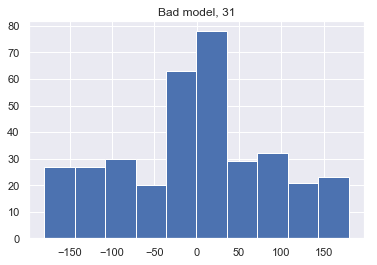

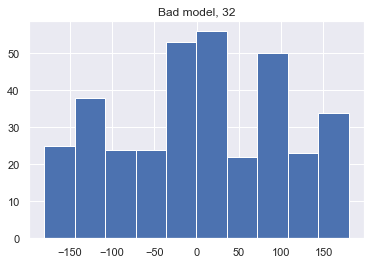

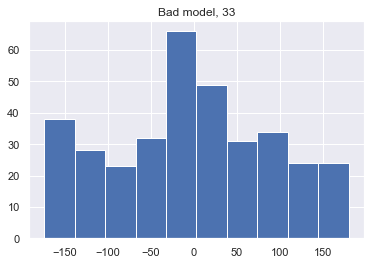

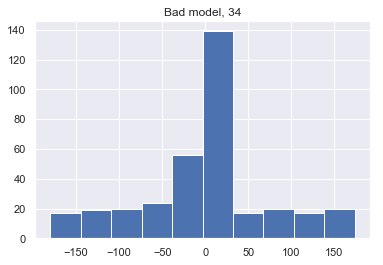

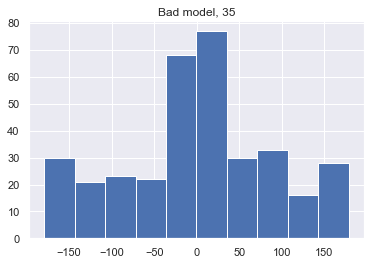

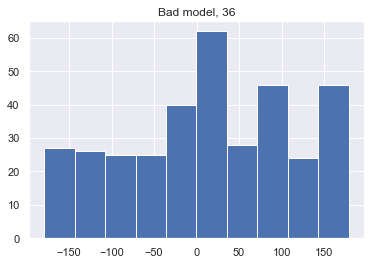

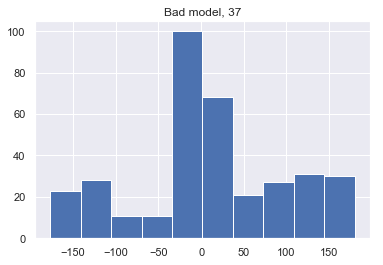

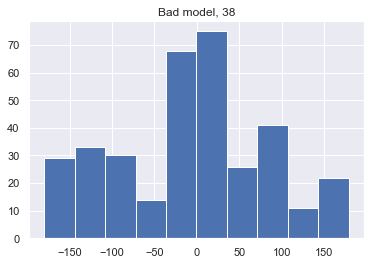

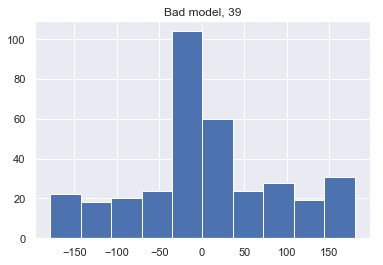

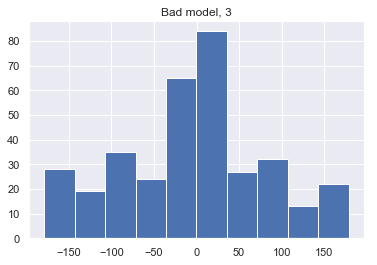

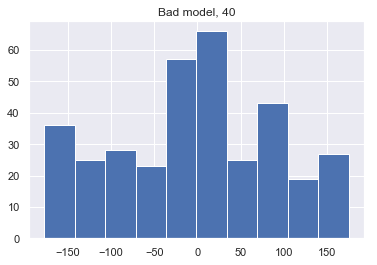

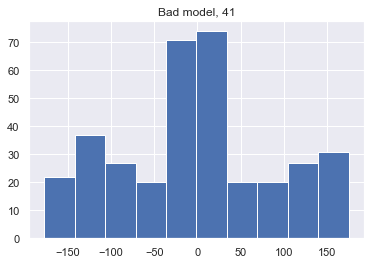

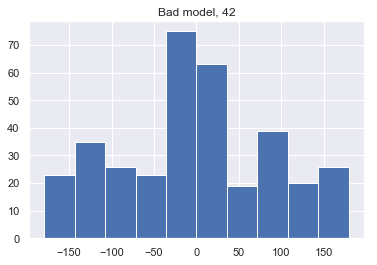

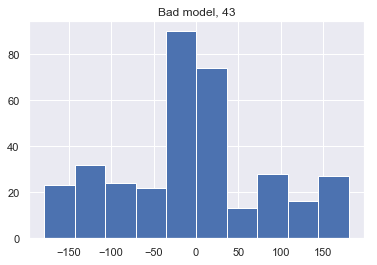

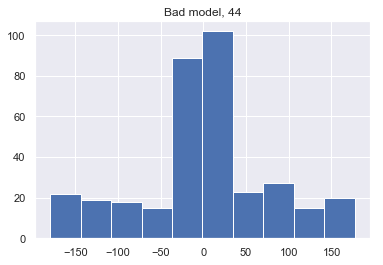

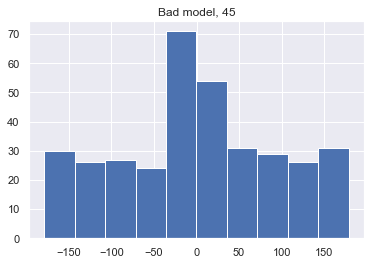

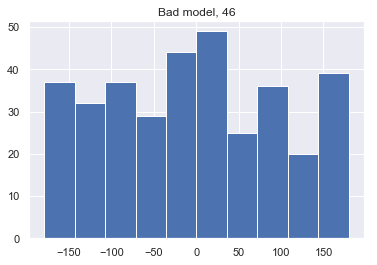

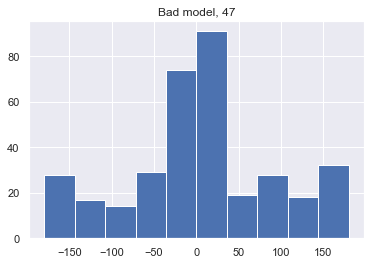

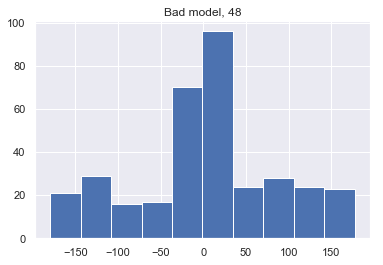

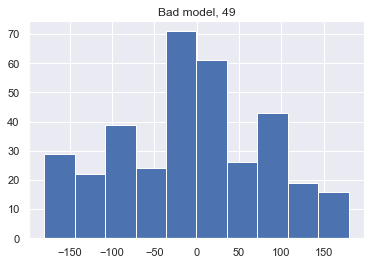

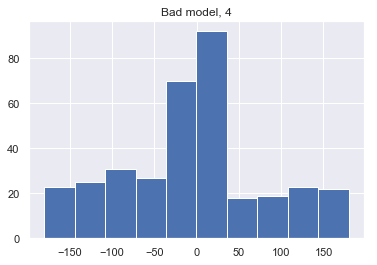

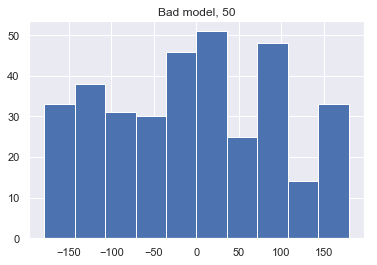

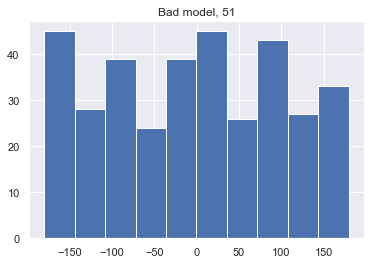

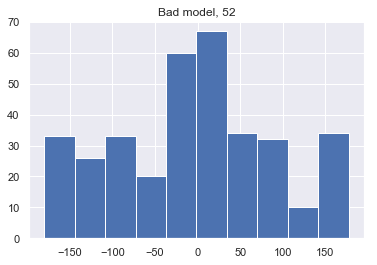

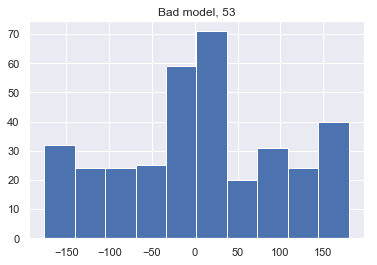

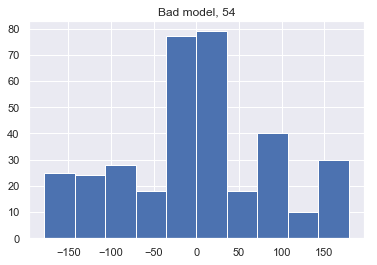

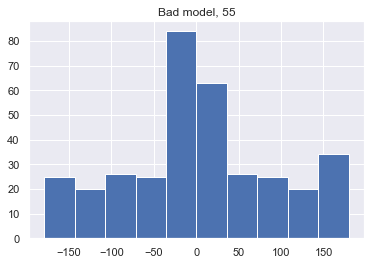

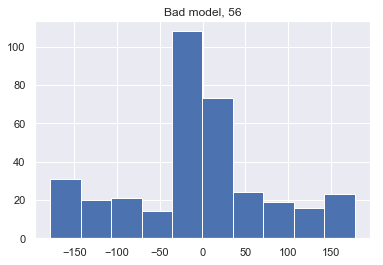

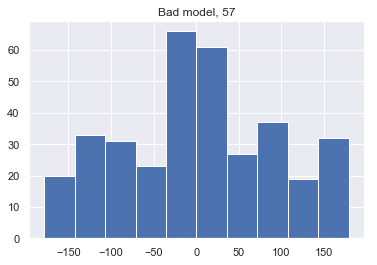

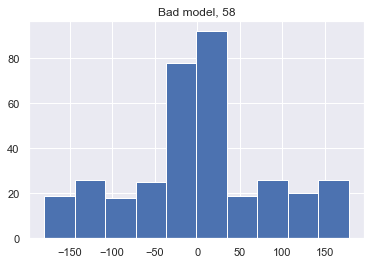

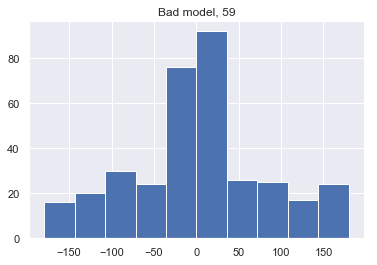

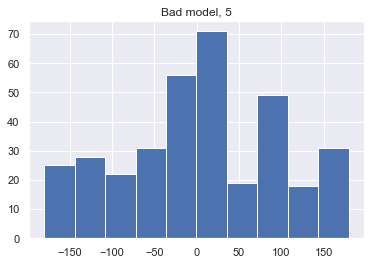

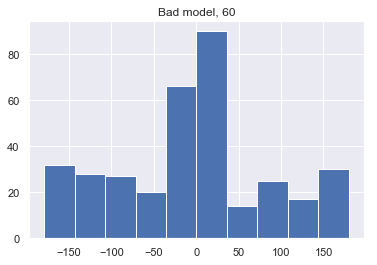

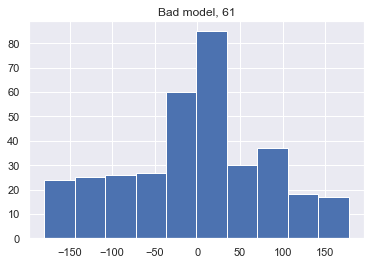

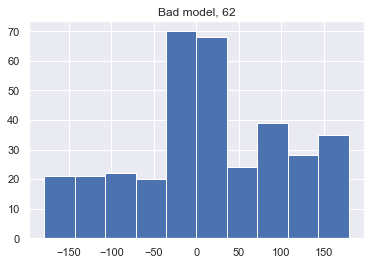

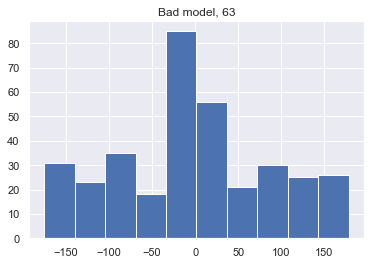

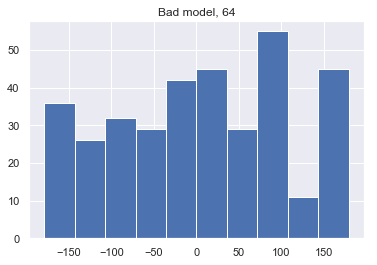

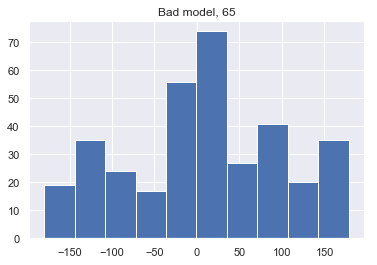

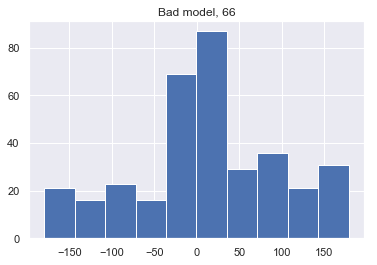

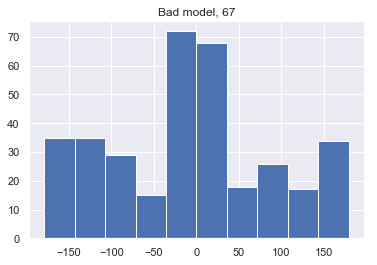

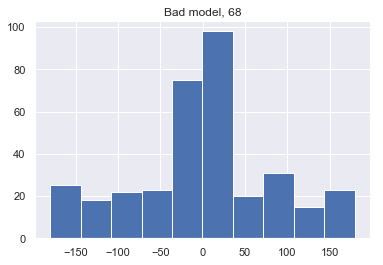

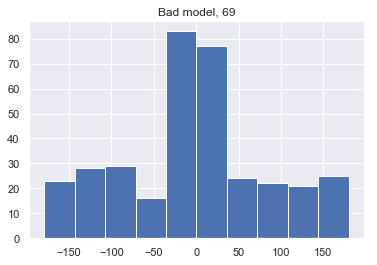

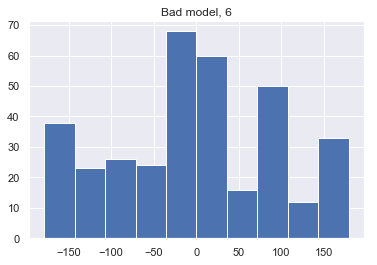

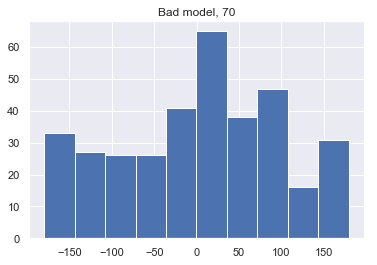

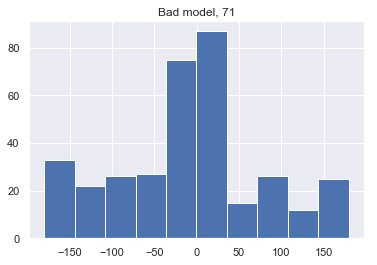

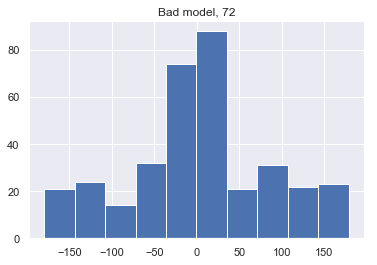

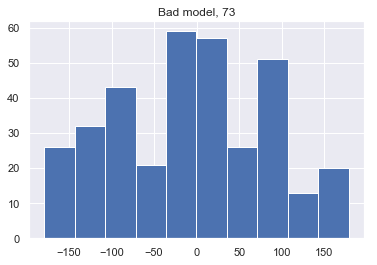

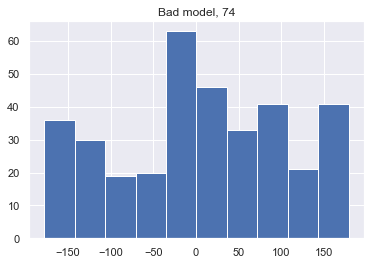

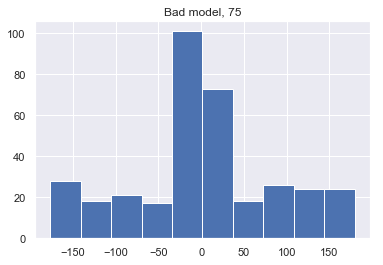

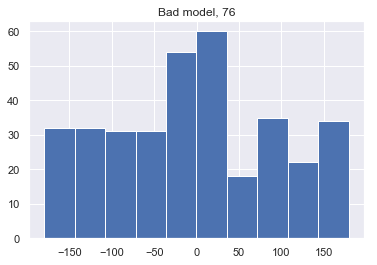

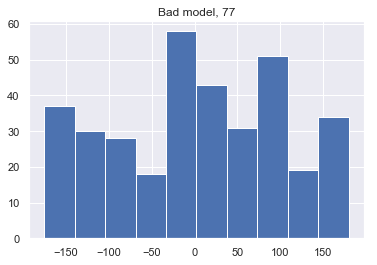

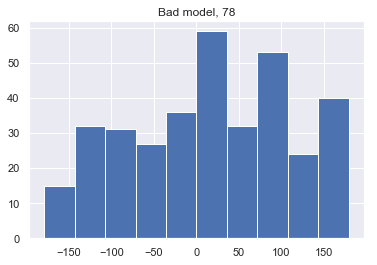

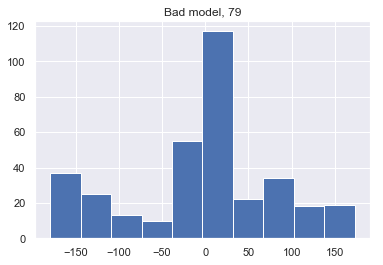

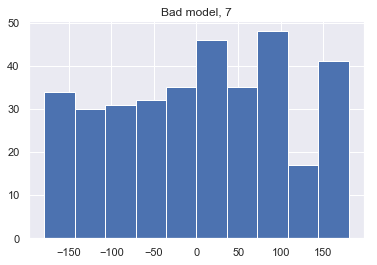

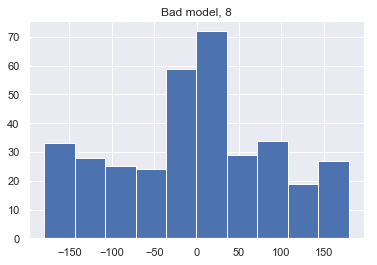

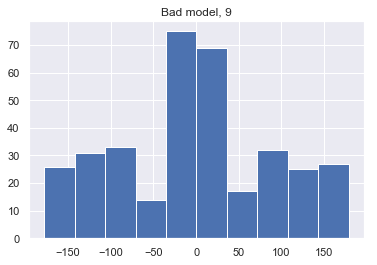

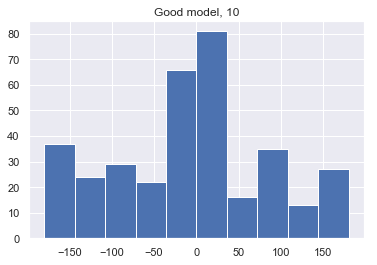

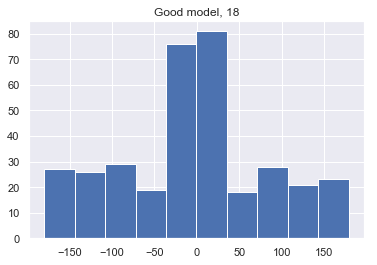

In [63]:
base = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/fits/'
experiment = 'nonresponseswap/'
good_models = findgoodmodels(base,experiment, gcutoff = 0.4,tasks = ['sir4_chunk.csv'])
plot_badmodels("Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/", good_models['sir4_chunk.csv'])

In [43]:
good_models

{'sir4_chunk.csv': array(['model10err.csv', 'model18err.csv', 'model27err.csv'], dtype=object),
 'sir4.csv': array(['model23err.csv', 'model27err.csv', 'model46err.csv',
        'model69err.csv'], dtype=object)}

all files: 80
Good files: 75
all files: 80
Good files: 79
all files: 80
Good files: 11
all files: 80
Good files: 10
all files: 80
Good files: 4
all files: 80
Good files: 3


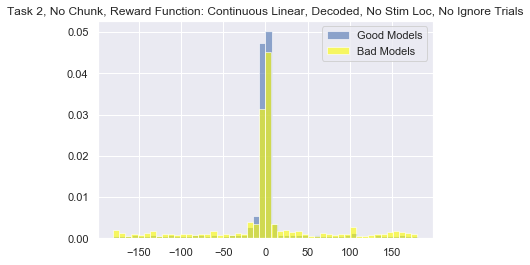

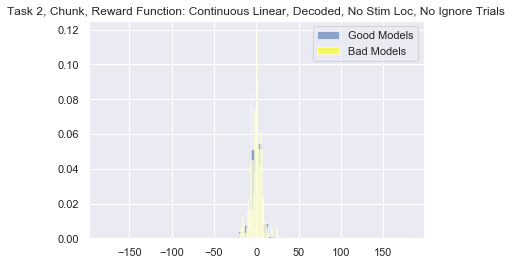

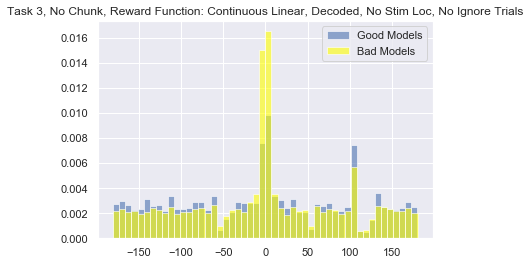

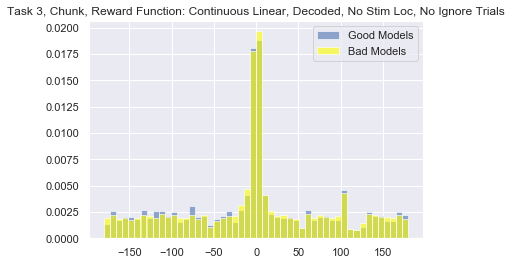

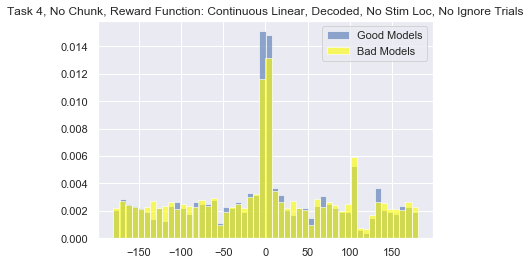

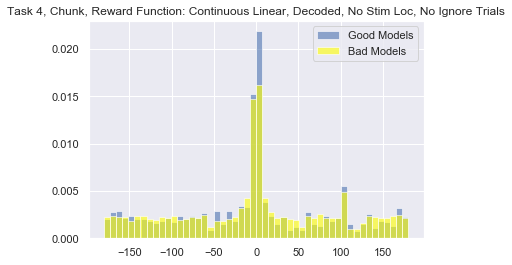

In [31]:
good_models = []
base = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/fits/'
experiment = 'nonresponseswap/'
good_models = findgoodmodels(base,experiment, gcutoff = 0.6)

base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
plot_allhist(base,base2,experiment, good_models = good_models, overlay = False)

all files: 80
plotting files: 56
all files: 80
plotting files: 69
all files: 80
plotting files: 2
all files: 80
plotting files: 2
all files: 80
plotting files: 1
all files: 80
plotting files: 2


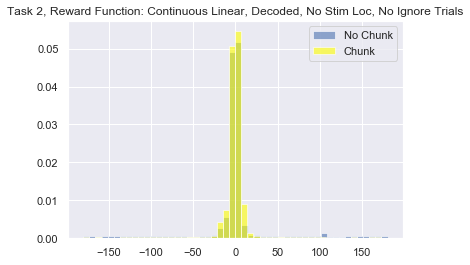

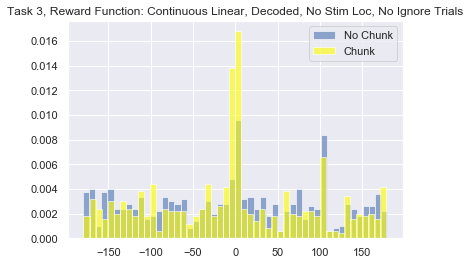

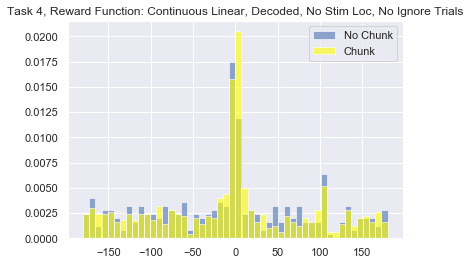

In [26]:
good_models = []
base = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/fits/'
experiment = 'nonresponseswap/'
good_models = findgoodmodels(base,experiment, gcutoff = 0.4)

base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
plot_allhist(base,base2,experiment, good_models = good_models, overlay = True)

In [14]:
good_models

[]

In [ ]:
#want to cut off not based on learning curve but based on guessing percentatge - need to do proper correspondence 
#between model number and model g/sd parameters from matlab to here.

(array([0.01664133, 0.06656533, 0.06656533, 0.13313065, 0.43267462,
        0.46595728, 0.33282663, 0.09984799, 0.03328266, 0.01664133]),
 array([-3.10347674, -2.50256328, -1.90164982, -1.30073636, -0.6998229 ,
        -0.09890945,  0.50200401,  1.10291747,  1.70383093,  2.30474439,
         2.90565785]),
 <a list of 10 Patch objects>)

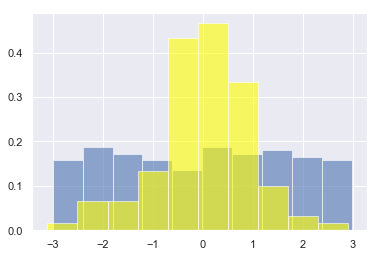

In [72]:
a = np.random.uniform(-3,3,1000)
b = np.random.normal(0,1,100)
plt.hist(a,density = True, alpha = 0.6)
plt.hist(b,density = True, alpha = 0.6, color = "yellow")

all files: 80
plotting files: 80
all files: 80
plotting files: 80
all files: 80
plotting files: 80
all files: 80
plotting files: 80
all files: 80
plotting files: 80
all files: 80
plotting files: 80


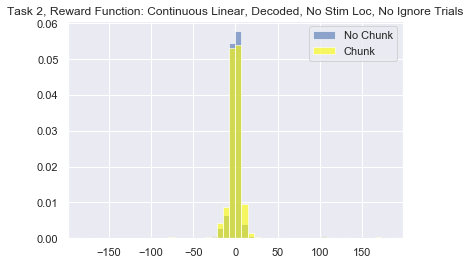

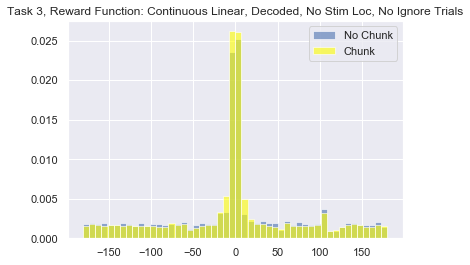

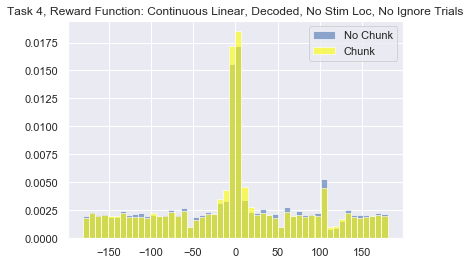

In [80]:
good_models = []
base = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/fits/'
experiment = ''
good_models = findgoodmodels(base,experiment, gcutoff = 1.0)

base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/"
plot_allhist(base,base2,experiment, good_models = good_models, overlay = True)

all files: 80
plotting files: 80
all files: 80
plotting files: 80
all files: 80
plotting files: 66
all files: 80
plotting files: 76
all files: 80
plotting files: 57
all files: 80
plotting files: 64


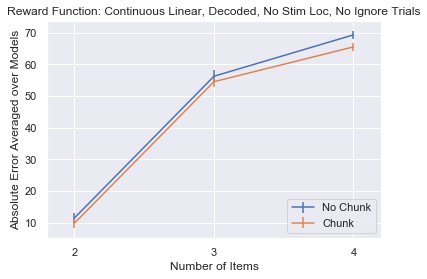

In [22]:
base = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/fits/'
experiment = ''
good_models = findgoodmodels(base,experiment, gcutoff = 0.85)

base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/"
mse_allmodels(base,base2,experiment, good_models = good_models)

all files: 80
plotting files: 80
all files: 80
plotting files: 79
all files: 80
plotting files: 54
all files: 80
plotting files: 64
all files: 80
plotting files: 19
all files: 80
plotting files: 41


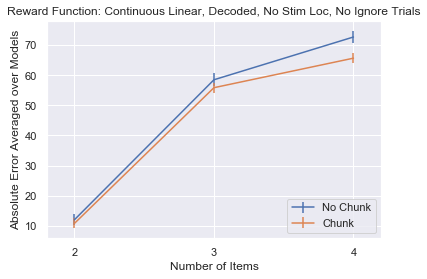

In [23]:
base = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/fits/'
experiment = 'sigma12/'
good_models = findgoodmodels(base,experiment)

base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/sigma12/"
mse_allmodels(base,base2,experiment, good_models = good_models)

all files: 80
plotting files: 80
all files: 80
plotting files: 79
all files: 80
plotting files: 36
all files: 80
plotting files: 37
all files: 80
plotting files: 7
all files: 80
plotting files: 17


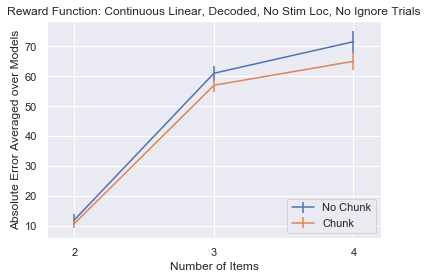

In [24]:
base = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/fits/'
experiment = 'sigma12/'
good_models = findgoodmodels(base,experiment, gcutoff = 0.6)

base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/sigma12/"
mse_allmodels(base,base2,experiment, good_models = good_models)

all files: 80
plotting files: 80
all files: 80
plotting files: 80
all files: 80
plotting files: 72
all files: 80
plotting files: 72
all files: 80
plotting files: 56
all files: 80
plotting files: 67


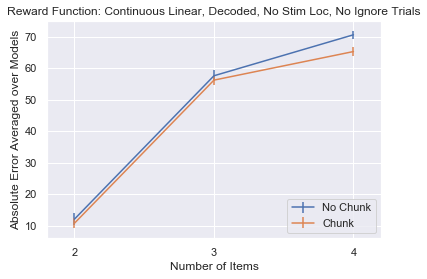

In [25]:
base = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/fits/'
experiment = 'sigma12/'
good_models = findgoodmodels(base,experiment, gcutoff = 0.85)

base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/sigma12/"
mse_allmodels(base,base2,experiment, good_models = good_models)

In [29]:
df = pd.read_csv('C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/fits/sir3.csv')
df_good = df[df['g'] <=0.7]
model_names = df_good['Name'].values
model_names
good_models = {"sir4": model_names}

In [ ]:
# bad,good = badmodels("Z:/leabra/examples/workingmemory/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/", cutoff = 80 )
plotbadmodels(bad,good)
bad,good = badmodels("Z:/leabra/examples/workingmemory/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/", cutoff= 80)
plotbadmodels(bad,good)

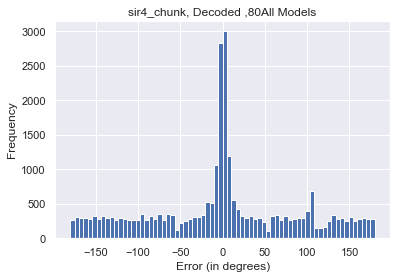

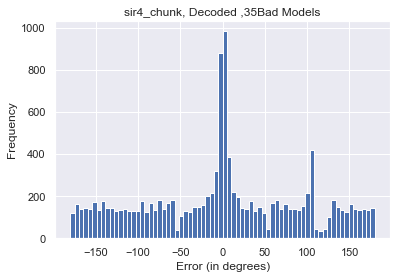

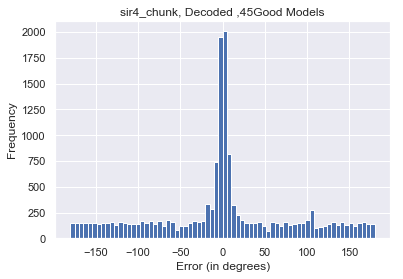

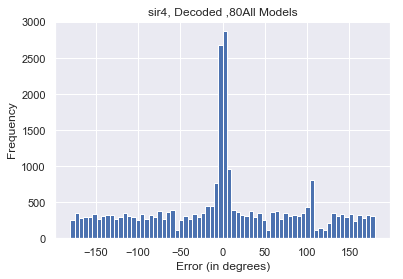

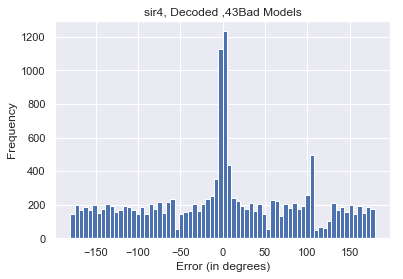

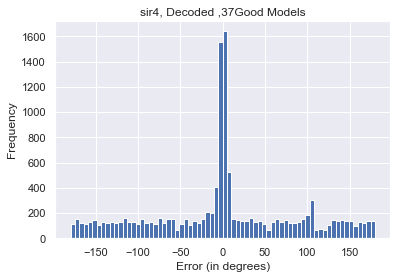

In [5]:
bad,good = badmodels("Z:/leabra/examples/workingmemory/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/", cutoff = 70 )
plotbadmodels(bad,good)
bad,good = badmodels("Z:/leabra/examples/workingmemory/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/", cutoff= 70)
plotbadmodels(bad,good)

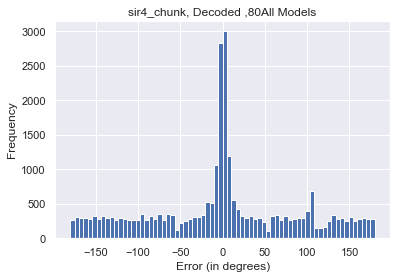

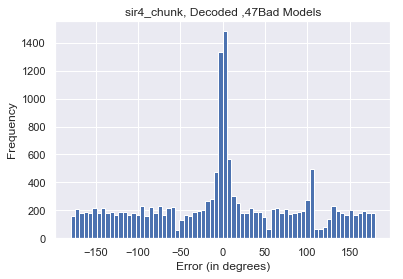

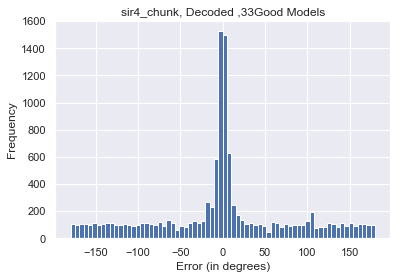

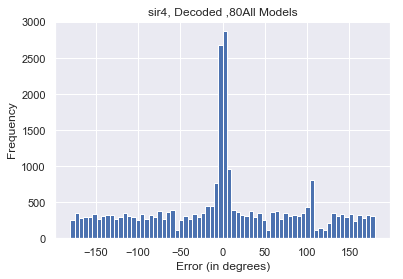

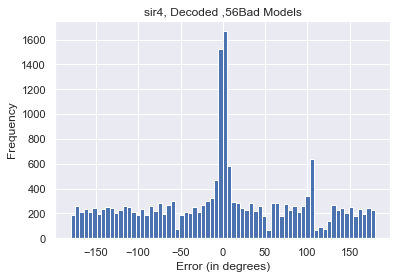

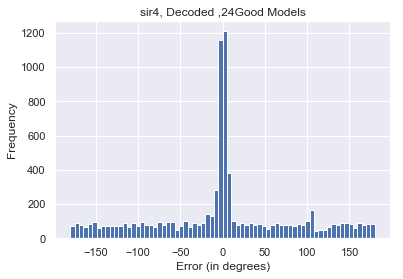

In [6]:
bad,good = badmodels("Z:/leabra/examples/workingmemory/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/", cutoff = 60 )
plotbadmodels(bad,good)
bad,good = badmodels("Z:/leabra/examples/workingmemory/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/", cutoff= 60)
plotbadmodels(bad,good)